<a href="https://colab.research.google.com/github/narjes-sardouk1/Projet_ML/blob/main/Test.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

***PARTIE CHARGEMENT DE DONNEES***



In [1]:
# 1. Upload du fichier: étape pour importer notre dataset dans Google Colab
from google.colab import files # importe le module pour permettre le téléversement de fichiers depuis l'ordinateur
import pandas as pd # importe la bibliothèque pandas pour manipuler les données sous forme de DataFrame
import io  # importe le module io pour gérer les flux de données en mémoire

uploaded = files.upload()# ouvre une fenêtre pour charger le fichier 'clean_kaggle_dataset.csv' depuis l'ordinateur

# 2. Importer le fichier (clean_kaggle_dataset.csv)
df = pd.read_csv(io.BytesIO(uploaded['clean_kaggle_dataset.csv'])) # lit le fichier 'clean_kaggle_dataset.csv' en mémoire et le convertit en DataFrame pandas nommé df

print(df.head()) # affiche les 5 premières lignes du dataset pour avoir un aperçu rapide des données
df.info()  # affiche des informations générales sur le DataFrame (colonnes, types de données, valeurs non nulles)

Saving clean_kaggle_dataset.csv to clean_kaggle_dataset.csv
   Unnamed: 0                                               text target
0           0  go jurong point crazy available bugis n great ...    ham
1           1                            ok lar joking wif u oni    ham
2           2  free entry wkly comp win fa cup final tkts st ...   spam
3           3                u dun say early hor u c already say    ham
4           4             nah think goes usf lives around though    ham
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5558 entries, 0 to 5557
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  5558 non-null   int64 
 1   text        5558 non-null   object
 2   target      5558 non-null   object
dtypes: int64(1), object(2)
memory usage: 130.4+ KB


Ce code permet d’importer le dataset clean_kaggle_dataset.csv, qui est un dataset de classification de SMS (spam/ham) nettoyé, dans l'environnement Google Colab, puis de le charger dans un DataFrame à l’aide de la bibliothèque pandas, afin d’explorer rapidement son contenu et de comprendre sa structure (colonnes, types de données, valeurs disponibles).

Les deux étiquettes de classification du dataset sont: Ham et Spam.

- HAM: qui représente un message légitime ou normal, c'est-à-dire un SMS ordinaire envoyé par une vraie personne.
- Spam: qui représente un message indésirable ou non sollicité, c'est-à-dire un SMS frauduleux.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


Ce code importe les bibliothèques essentielles pour l’analyse de données en Python : pandas pour manipuler les datasets sous forme de tableaux, numpy pour effectuer des calculs numériques, ainsi que matplotlib.pyplot et seaborn pour créer des visualisations graphiques et explorer les données de manière visuelle.

In [3]:
#Chargement du fichier.csv 'clean_kaggle_dataset.csv'
df = pd.read_csv('clean_kaggle_dataset.csv')

***PHASE 1: EXPLORATION DE DONNEES***

In [4]:
# Afficher les 10 premières lignes
df.head(10)

,Unnamed: 0,text,target
0,0,go jurong point crazy available bugis n great ...,ham
1,1,ok lar joking wif u oni,ham
2,2,free entry wkly comp win fa cup final tkts st ...,spam
3,3,u dun say early hor u c already say,ham
4,4,nah think goes usf lives around though,ham
5,5,freemsg hey darling week word back like fun st...,spam
6,6,even brother like speak treat like aids patent,ham
7,7,per request melle melle oru minnaminunginte nu...,ham
8,8,winner valued network customer selected receiv...,spam
9,9,mobile months u r entitled update latest colou...,spam


In [5]:
# Description de la base de données
# Afficher le nombre total de messages
print(f"Nombre total de messages : {len(df)}")

# Afficher la distribution des classes (nombre d’occurrences par classe)
print(f"\nDistribution des classes :")
print(df['target'].value_counts())

# Afficher les pourcentages de chaque classe
print(f"\nPourcentages :")
print(df['target'].value_counts(normalize=True).mul(100).round(2).astype(str) + " %")

Nombre total de messages : 5558

Distribution des classes :
target
ham     4811
spam     747
Name: count, dtype: int64

Pourcentages :
target
ham     86.56 %
spam    13.44 %
Name: proportion, dtype: object


Ce code montre une description statistique du dataset en trois étapes. Il commence par montrer le nombre total de messages. Ensuite, il montre la distribution des classes en comptant le nombre exact de messages HAM et SPAM. Finalement, il calcule le pourcentage de chaque classe pour mieux voir le déséquilibre entre les deux catégories. Le dataset contient 86.6 % de messages HAM et 13.4 % de messages SPAM.

In [6]:
# Type des colonnes
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5558 entries, 0 to 5557
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  5558 non-null   int64 
 1   text        5558 non-null   object
 2   target      5558 non-null   object
dtypes: int64(1), object(2)
memory usage: 130.4+ KB
None


Le dataset contient 3 colonnes et 5 558 entrées. Toutes les entrées sont complètes, il n'y a donc aucune valeur manquante. La colonne Unnamed: 0 est de type entier (int64) et représente simplement l'index original(un numéro de ligne attribué automatiquement à chaque message lors de la création du dataset, allant de 0 à 5557.), il ne contient aucune information utile pour l'analyse ou la classification, c'est juste un identifiant numérique qui permet de repérer chaque ligne. On peut le supprimer sans aucun impact sur le modèle.

Les colonnes text et target sont de type objet, ce qui signifie qu'elles contiennent du texte.
- La colonne text contient le contenu du SMS, tandis que la colonne target contient l'étiquette associée à chaque SMS, qui peut être soit HAM, soit SPAM. Puisqu'il n'y a pas de valeurs manquantes, le dataset est propre et prêt à être utilisé sans nécessiter de traitement des données manquantes.

In [7]:
# Vérification précise des valeurs nulles
print("\nValeurs manquantes par colonne :")
print(df.isnull().sum())


Valeurs manquantes par colonne :
Unnamed: 0    0
text          0
target        0
dtype: int64


Ce code vérifie si il y a des valeurs manquantes dans chaque colonne du dataset. Le résultat montre qu'il n'y a pas de valeurs nulles dans les colonnes.

- 0 valeur manquante pour Unnamed: 0, text et target, ce qui signifie que le dataset est complet et ne nécessite aucun traitement de données manquantes avant d'être utilisé dans le modèle.

In [8]:
# Vérification des doublons
print(f"\nNombre de lignes dupliquées : {df.duplicated().sum()}")
df.head()


Nombre de lignes dupliquées : 0


,Unnamed: 0,text,target
0,0,go jurong point crazy available bugis n great ...,ham
1,1,ok lar joking wif u oni,ham
2,2,free entry wkly comp win fa cup final tkts st ...,spam
3,3,u dun say early hor u c already say,ham
4,4,nah think goes usf lives around though,ham


Ce code vérifie la présence de lignes dupliquées dans le dataset. Le résultat indique 0 doublon, ce qui signifie que chaque SMS est unique et qu'aucune ligne n'est répétée. Le dataset est donc fiable et ne nécessite pas de suppression de doublons avant l'entraînement du modèle.

In [9]:
#Suppression des colonnes inutiles
colonnes_inutiles = ['Unnamed: 0']
df = df.drop(columns=colonnes_inutiles, errors='ignore')
#Vérification
df.head()

,text,target
0,go jurong point crazy available bugis n great ...,ham
1,ok lar joking wif u oni,ham
2,free entry wkly comp win fa cup final tkts st ...,spam
3,u dun say early hor u c already say,ham
4,nah think goes usf lives around though,ham


Ce code supprime la colonne Unnamed: 0 qui représente l'ancien index et n'apporte aucune information utile pour la classification.

- Après suppression, le dataset ne contient plus que les deux colonnes essentielles : text (le contenu du SMS) et target (l'étiquette HAM ou SPAM)

In [10]:
# Renommer les colonnes 'text' en 'message' et 'target' en 'Ham/Spam'
df = df.rename(columns={'text': 'message', 'target': 'Ham/Spam'})
#Vérification
df.head()

,message,Ham/Spam
0,go jurong point crazy available bugis n great ...,ham
1,ok lar joking wif u oni,ham
2,free entry wkly comp win fa cup final tkts st ...,spam
3,u dun say early hor u c already say,ham
4,nah think goes usf lives around though,ham


Ce code renomme les colonnes du dataset pour les rendre plus explicites et compréhensibles : text devient message et target devient Ham/Spam.
Cette étape n'affecte pas les données. Elle améliore toutefois la lisibilité du dataset. Cela se produit lors des étapes suivantes d'analyse et de modélisation du dataset.

Ham/Spam
ham     4811
spam     747
Name: count, dtype: int64


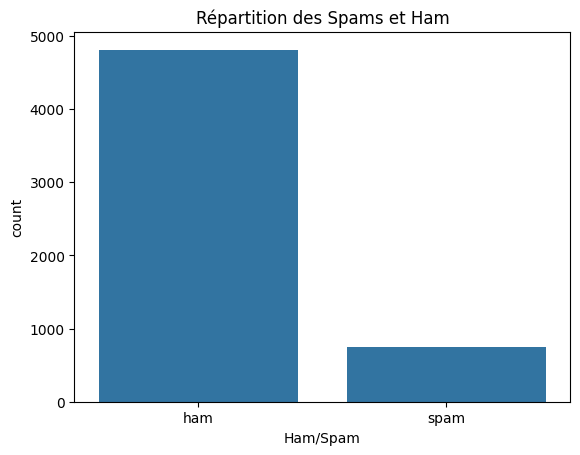

In [11]:
# Distribution des classes : Spam et Ham
# Afficher le nombre de messages pour chaque classe (Ham et Spam)
print(df['Ham/Spam'].value_counts())

# Créer un graphique en barres pour visualiser la répartition des classes
sns.countplot(x='Ham/Spam', data=df)

# Ajouter un titre au graphique
plt.title('Répartition des Spams et Ham')

# Afficher le graphique
plt.show()

Ce code présente la répartition des classes de deux manières. D'abord numériquement avec la fonction value_counts() qui confirme 4 811 messages HAM et 747 messages SPAM, puis visuellement via un graphique en barres généré avec seaborn.

- Ce graphique montre clairement que les messages HAM sont beaucoup plus nombreux que les messages SPAM. Il y a environ 6 fois plus de messages HAM que de messages SPAM.
- C'est une information importante lors de l'entraînement du modèle, , car ce déséquilibre peut biaiser les résultats en faveur de la classe majoritaire (HAM).

In [12]:
# Exemples de messages
print("\n--- Exemple de messages HAM ---")
print(df[df['Ham/Spam'] == 'ham']['message'].iloc[0])
print(df[df['Ham/Spam'] == 'ham']['message'].iloc[1])

print("\n--- Exemple de messages SPAM ---")
print(df[df['Ham/Spam'] == 'spam']['message'].iloc[0])
print(df[df['Ham/Spam'] == 'spam']['message'].iloc[1])


--- Exemple de messages HAM ---
go jurong point crazy available bugis n great world la e buffet cine got amore wat
ok lar joking wif u oni

--- Exemple de messages SPAM ---
free entry wkly comp win fa cup final tkts st may text fa receive entry question std txt rate c apply
freemsg hey darling week word back like fun still tb ok xxx std chgs send rcv


Ce code affiche deux exemples concrets de messages pour chaque classe afin d'illustrer visuellement la différence entre un HAM et un SPAM. Les messages HAM sont des conversations informelles et naturelles entre personnes ("ok lar joking wif u oni"), tandis que les messages SPAM contiennent des expressions typiques de messages frauduleux comme des offres de gains ("free entry wkly comp win") ou des sollicitations suspectes ("freemsg hey darling..."), ce qui confirme que le contenu textuel est suffisamment distinctif pour entraîner un modèle de classification.

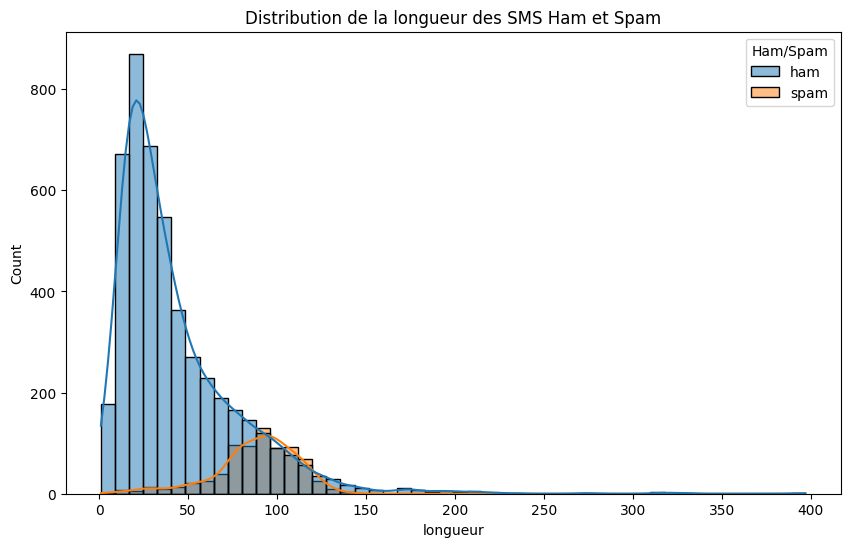

In [13]:
# Longueur des messages
# Calculer la longueur de chaque message et la stocker dans une nouvelle colonne
df['longueur'] = df['message'].apply(len)

# Définir la taille de la figure du graphique
plt.figure(figsize=(10, 6))

# Tracer la distribution des longueurs des messages selon Ham/Spam
sns.histplot(data=df, x='longueur', hue='Ham/Spam', kde=True, bins=50)

# Ajouter un titre au graphique
plt.title('Distribution de la longueur des SMS Ham et Spam')

# Afficher le graphique
plt.show()

Ce code calcule la longueur de chaque message en nombre de caractères et la stocke dans une nouvelle colonne longueur, puis trace un histogramme comparatif entre les messages HAM et SPAM.
Le graphique obtenu montre clairement deux tendances bien distinctes :

- Les messages HAM, représentés en bleu, sont généralement courts, atteignent un pic de comptage autour de 800 à 880 messages pour les longueurs courtes (la plupart d'entre eux contenant entre 0 et 50 caractères), avec un pic très élevé autour de 20-30 caractères,ce qui reflète le caractère spontané et concis des conversations quotidiennes de tous les jours.

- En revanche, les messages SPAM, affichés en orange, ont une distribution plus large et étalée, atteignent un pic d'environ 120 à 130 messages. Ils sont surtout concentrés entre 70 et 150 caractères, car ils contiennent souvent plus d'informations à caractère commercial ou frauduleux.

La longueur du message constitue donc un indicateur utile pour distinguer les deux classes HAM ou SPAM.

***PHASE 2: VERIFICATION ET PRETRAITEMENT DE DONNEES***

In [14]:
# Vérifier s’il existe de la ponctuation
import string

# Vérifie si chaque message contient de la ponctuation (True/False)
df['has_punctuation'] = df['message'].apply(lambda x: any(char in string.punctuation for char in str(x)))
#Voir les messages concernés :
df[df['has_punctuation'] == True].head()

,message,Ham/Spam,longueur,has_punctuation


Ce code vérifie si les messages du dataset contiennent de la ponctuation afin de s'assurer que le fichier clean_kaggle_dataset.csv est bien propre et prêt à l'emploi.

Pour chaque message, la fonction lambda parcourt chaque caractère et retourne True si au moins un signe de ponctuation est détecté, ou False dans le cas contraire. Le résultat est stocké dans une nouvelle colonne has_punctuation. Le fait que le tableau affiché soit vide confirme qu'aucun message ne contient de ponctuation, ce qui valide que le dataset est effectivement nettoyé et peut être utilisé directement sans nécessiter d'étape de prétraitement supplémentaire.

In [15]:
#Vérifier si le message est en minuscules
# Vérifie si chaque message est en minuscules
df['is_lowercase'] = df['message'].apply(lambda x: str(x).islower())
#Voir les messages qui ne sont PAS en minuscules :
df[df['is_lowercase'] == False].head()

,message,Ham/Spam,longueur,has_punctuation,is_lowercase


De même, ce code vérifie si tous les messages du dataset sont bien écrits en minuscules. Pour chaque message, la fonction islower() retourne True si le message est entièrement en minuscules, ou False dans le cas contraire. Le résultat vide confirme qu'aucun message ne contient de majuscules, ce qui valide que le dataset clean_kaggle_dataset.csv est bien normalisé et uniforme sur ce point.

*VERIFICATION DES STOP WORDS*

Les stop words sont des mots très fréquents dans un corpus textuel mais qui n'apportent aucune information utile pour la classification, comme les pronoms ou les conjonctions.
Il est important de les supprimer car ils ajoutent du désordre et réduisent l'importance des mots vraiment significatifs lorsqu'on utilise la méthode TF-IDF par la suite. Cela peut avoir un impact négatif sur les résultats de notre modèle ce qui peut dégrader les performances.

 Dans notre ensemble de données, nous avons identifié **188 stop words** qui peuvent être classés en trois groupes:

 - Tout d'abord, il y a les **155 stop words standard anglais** qui proviennent de la liste sklearn et incluent des mots comme `call`, `get`, `go` ou `please`.

- Ensuite, nous avons **12 stop words spécifiques à notre corpus** qui sont principalement des lettres seules sans importance, comme `u`, `p`, `r` ou `n`

- Enfin, nous avons **29 abréviations SMS** qui sont propres à notre ensemble de données et comprennent des termes anglais abrégés comme `ur`, `r`, `txt` ou `pls`, des expressions Singlish comme `lor`, `da` ou `wat`, ainsi que des balises HTML codées comme `gt` ou `lt`.

Remarque : Le total des trois catégories donne 155 + 12 + 29 = 196 termes. Cependant, certains termes apparaissent dans plusieurs catégories en même temps, comme par exemple les termes u, r, c et v. Cela signifie que lorsque l'on supprime les doublons, l'union finale ne contient que 188 termes uniques.

Afin de garantir une identification complète et fiable des stop words, nous avons utilisé deux méthodes de vérification citées ci-aprés:

- **La première méthode consiste à vérifier par rapport à une liste officielle.** Nous comparons les mots du corpus à une liste de stop words standard fournie par la bibliothèque sklearn. Cette approche permet d'identifier rapidement les mots grammaticalement non informatifs reconnus universellement en anglais.

- **La deuxième méthode est basée sur une analyse de fréquence.** Nous examinons la fréquence d'apparition de chaque mot dans l'ensemble du corpus. Les mots qui apparaissent de manière excessive dans les documents sans apporter de valeur discriminante sont considérés comme des stop words spécifiques à notre dataset. C'est le cas des lettres isolées et des abréviations SMS.

In [16]:
#1. Vérification par rapport à une liste officielle

import pandas as pd

# 1. Liste de stop-words anglais (ou récupérée via sklearn/nltk)
stop_words_en = [
    # A — Stop words standard anglais
    "call", "get", "go", "one", "see", "still", "back", "take", "please",
    "would", "every", "could", "many", "even", "never", "nothing",
    "i", "me", "my", "we", "our", "you", "your", "he", "she", "it",
    "they", "them", "this", "that", "these", "those", "am", "is",
    "are", "was", "were", "be", "been", "being", "have", "has", "had",
    "do", "does", "did", "but", "if", "or", "because", "as", "until",
    "while", "of", "at", "by", "for", "with", "about", "against", "between", "into", "through", "during", "before", "after", "above",
    "below", "to", "from", "up", "down", "in", "out", "on", "off",
    "over", "under", "again", "further", "then", "once",
    # B — Stop words spécifiques corpus
    "u", "p", "r", "n", "k", "c", "b", "e", "x", "w", "v", "g",

    # C — Abréviations SMS / Singlish / HTML
    "ur", "txt", "r", "ok", "pls", "im", "dun", "nt",
    "lor", "da", "na", "wat", "la", "lar", "ah", "oni",
    "gt", "lt"]

# Définit une fonction qui affiche des exemples de messages(5 messages) contenant des stopwords
def display_stopword_examples(dataframe, text_column, stop_list, n_examples=5):
    """
    Identifie et affiche les messages contenant des stopwords.
    """
    # Fonction interne qui récupère les stopwords présents dans un texte
    def get_found_stops(text):
        # Découpe le texte et identifie les intersections avec la liste
        words = str(text).lower().split()
        # Convertit le texte en minuscule et le découpe en mots
        return [w for w in words if w in stop_list]
        # Retourne uniquement les mots présents dans la liste des stopwords

    # Création d'une copie temporaire pour ne pas polluer le df original
    temp_df = dataframe.copy()
    # Ajoute une colonne contenant les stopwords détectés dans chaque message
    temp_df['detected_stops'] = temp_df[text_column].apply(get_found_stops)

    # On ne garde que les lignes où au moins un stopword est trouvé
    examples = temp_df[temp_df['detected_stops'].map(len) > 0].head(n_examples)

    # Filtre les messages contenant des stopwords et limite à n exemples
    if examples.empty:
      # Vérifie si aucun message contenant des stopwords n’a été trouvé
        print("Aucun stopword détecté dans les messages.")
    else:
      # Affiche le nombre d'exemples trouvés
        print(f"--- Affichage de {len(examples)} exemples avec leurs stopwords ---")
        # Parcourt chaque ligne filtrée pour afficher le message et ses stop words
        for i, row in examples.iterrows():
          # Affiche le message original
            print(f"\nMessage original : {row[text_column]}")
            # Affiche les stop words détectés en supprimant les doublons avec set()
            print(f"Stopwords trouvés : {list(set(row['detected_stops']))}") # set() pour éviter les doublons
            # Affiche une ligne de séparation entre les exemples
            print("-" * 30)

# Appel de la fonction sur le dataframe df avec la colonne 'message' et la liste de stop words définie
display_stopword_examples(df, 'message', stop_words_en)

--- Affichage de 5 exemples avec leurs stopwords ---

Message original : go jurong point crazy available bugis n great world la e buffet cine got amore wat
Stopwords trouvés : ['go', 'e', 'wat', 'la', 'n']
------------------------------

Message original : ok lar joking wif u oni
Stopwords trouvés : ['lar', 'u', 'oni', 'ok']
------------------------------

Message original : free entry wkly comp win fa cup final tkts st may text fa receive entry question std txt rate c apply
Stopwords trouvés : ['txt', 'c']
------------------------------

Message original : u dun say early hor u c already say
Stopwords trouvés : ['dun', 'u', 'c']
------------------------------

Message original : freemsg hey darling week word back like fun still tb ok xxx std chgs send rcv
Stopwords trouvés : ['back', 'still', 'ok']
------------------------------


Ce code implémente la **première méthode de vérification** des stop words en comparant chaque message du dataset avec une liste officielle prédéfinie regroupant les trois catégories identifiées (stop words standard anglais, stop words spécifiques au corpus et abréviations SMS). La fonction `display_stopword_examples` parcourt chaque message, le découpe en mots, détecte les intersections avec la liste de stop words et affiche 5 exemples concrets avec les stop words trouvés dans chaque message.

* Les résultats confirment la présence de stop words dans les messages : par exemple, le message *"go jurong point crazy available bugis n great world la e buffet cine got amore wat"* contient 5 stop words (`go`, `wat`, `la`, `n`, `e`), tandis que le message *"ok lar joking wif u oni"* en contient 4 (`u`, `oni`, `lar`, `ok`). Ces stop words sont bien répartis entre les trois catégories et leur suppression permettra d'améliorer la qualité de la vectorisation TF-IDF par la suite.

In [17]:
#2. Vérification par analyse de fréquence
from collections import Counter

# On regroupe tout le message et on compte les mots
all_words = ' '.join(df['message'].str.lower()).split()
word_counts = Counter(all_words)

# On affiche les 10 mots les plus fréquents
print("Top 10 des mots les plus fréquents (bruts) :")
for word, count in word_counts.most_common(10):
    print(f"{word}: {count}")

Top 10 des mots les plus fréquents (bruts) :
u: 1210
call: 606
get: 395
ur: 385
gt: 311
lt: 309
ok: 290
free: 287
go: 283
know: 260


Ce code implémente la deuxième méthode de vérification des stop words par analyse de fréquence. Il regroupe tous les mots de la colonne message en une seule chaîne de caractères, les convertit en minuscules, puis utilise Counter pour compter les occurrences de chaque mot et afficher le top 10 des mots les plus fréquents.

Les résultats confirment la présence de stop words parmi les mots les plus fréquents: Des mots comme u (1210 occurrences), ur (385), gt (311), lt (309) et ok (290)  sont souvent utilisés dans les SMS, mais ils ne veulent pas dire grand-chose.D'autres mots, comme call (606), get (395) et go (283), sont des mots courants en anglais, mais ils ne sont pas importants pour déterminer si un message est du SPAM ou non. Seul le mot free (287 occurrences) apparaît souvent dans les messages SPAM, il est donc utile pour les identifier. Cela confirme qu'il est important de supprimer ces mots avant de traiter les messages pour les classer.

In [18]:
# Liste de stopwords (si déjà définie)
stopwords_list = [
    # A — Stop words standard anglais
    "call", "get", "go", "one", "see", "still", "back", "take", "please",
    "would", "every", "could", "many", "even", "never", "nothing",
    "i", "me", "my", "we", "our", "you", "your", "he", "she", "it",
    "they", "them", "this", "that", "these", "those", "am", "is",
    "are", "was", "were", "be", "been", "being", "have", "has", "had",
    "do", "does", "did", "but", "if", "or", "because", "as", "until",
    "while", "of", "at", "by", "for", "with", "about", "against", "between", "into", "through", "during", "before", "after", "above",
    "below", "to", "from", "up", "down", "in", "out", "on", "off",
    "over", "under", "again", "further", "then", "once",
    # B — Stop words spécifiques corpus
    "u", "p", "r", "n", "k", "c", "b", "e", "x", "w", "v", "g",

    # C — Abréviations SMS / Singlish / HTML
    "ur", "txt", "r", "ok", "pls", "im", "dun", "nt",
    "lor", "da", "na", "wat", "la", "lar", "ah", "oni",
    "gt", "lt"
]

# fonction de nettoyage
# Définition de la fonction de suppression des stop words qui prend un message en entrée
def remove_stopwords(text):
    words = str(text).lower().split()
    # Filtre les mots en conservant uniquement ceux qui ne figurent pas dans la liste de stop words
    cleaned_words = [w for w in words if w not in stopwords_list]
    # Réassemble les mots filtrés en une seule chaîne de caractères et la retourne
    return " ".join(cleaned_words)

# application sur tout le dataset
# Applique la fonction remove_stopwords sur chaque message de la colonne 'message'
# et stocke le résultat nettoyé dans une nouvelle colonne 'clean_message'
df["clean_message"] = df["message"].apply(remove_stopwords)
# vérification
# Affiche les 10 premiers messages avant et après suppression des stop words
# pour vérifier visuellement que le nettoyage a été correctement effectué
print(df[["message", "clean_message"]].head(10))

                                             message  \
0  go jurong point crazy available bugis n great ...   
1                            ok lar joking wif u oni   
2  free entry wkly comp win fa cup final tkts st ...   
3                u dun say early hor u c already say   
4             nah think goes usf lives around though   
5  freemsg hey darling week word back like fun st...   
6     even brother like speak treat like aids patent   
7  per request melle melle oru minnaminunginte nu...   
8  winner valued network customer selected receiv...   
9  mobile months u r entitled update latest colou...   

                                       clean_message  
0  jurong point crazy available bugis great world...  
1                                         joking wif  
2  free entry wkly comp win fa cup final tkts st ...  
3                          say early hor already say  
4             nah think goes usf lives around though  
5  freemsg hey darling week word like fun tb xxx ... 

Ce code regroupe les trois étapes de suppression des stop words en un seul bloc. D'abord, la liste de stop words stopwords_list est définie en regroupant et combinant les trois catégories que nous avons identifiées précédemment. Ces catégories comprennent les stop words standard anglais, stop words spécifiques au corpus que nous étudions et les abréviations utilisées dans les messages SMS. Ensuite, la fonction remove_stopwords est appliquée à chaque message de la colonne message. Cela nous permet de produire une version nettoyée de chaque message, qui sera stockée dans une nouvelle colonne appelée clean_message.

- Les résultats montrent clairement que la suppression des stop words s'est déroulée comme prévu. Par exemple, le message “ok lar joking wif u oni” a été simplifié en “joking wif” après avoir supprimé les mots inutiles tels que “ok", “lar", “u” et “oni". De même, le message “go jurong point crazy available bugis n great world...” a perdu les termes “go” et “n” pour ne conserver que les mots qui apportent de l'information. Le dataset est maintenant prêt pour la prochaine étape, qui consiste à appliquer la vectorisation TF-IDF.

In [19]:
# vérifier les Valeurs manquantes:
print(df['Ham/Spam'].isna().sum())

0


Ce code vérifie si la colonne Ham/Spam contient des valeurs manquantes après l'étape de nettoyage. Le résultat 0 confirme qu'aucune valeur nulle n'a été introduite lors de la suppression des stop words, ce qui valide que le dataset reste complet et intègre avant de passer à l'étape de vectorisation TF-IDF.

In [20]:
#vérifier Valeurs différentes de "ham" et "spam":
df['Ham/Spam'].unique()

array(['ham', 'spam'], dtype=object)

Ce code vérifie les valeurs uniques présentes dans la colonne Ham/Spam. Le résultat confirme que la colonne ne contient que deux valeurs distinctes : ham et spam, sans aucune valeur inattendue ou mal orthographiée. Le dataset est donc propre et cohérent au niveau des étiquettes de classification.

In [21]:

# Encodage des classes : ham = 0, spam = 1
df['Ham/Spam'] = df['Ham/Spam'].map({'ham': 0, 'spam': 1})
#Afficher
df.head()

,message,Ham/Spam,longueur,has_punctuation,is_lowercase,clean_message
0,go jurong point crazy available bugis n great ...,0,82,False,True,jurong point crazy available bugis great world...
1,ok lar joking wif u oni,0,23,False,True,joking wif
2,free entry wkly comp win fa cup final tkts st ...,1,101,False,True,free entry wkly comp win fa cup final tkts st ...
3,u dun say early hor u c already say,0,35,False,True,say early hor already say
4,nah think goes usf lives around though,0,38,False,True,nah think goes usf lives around though


Ce code encode les étiquettes de la colonne Ham/Spam en valeurs numériques : ham devient 0 et spam devient 1. Cette étape est indispensable car les algorithmes de machine learning, notamment le Naive Bayes, ne peuvent pas traiter directement des valeurs textuelles, ils nécessitent des entrées numériques pour effectuer leurs calculs mathématiques. En transformant les étiquettes en 0 et 1, on permet au modèle d'interpréter correctement les classes cibles et d'effectuer l'apprentissage de manière efficace.

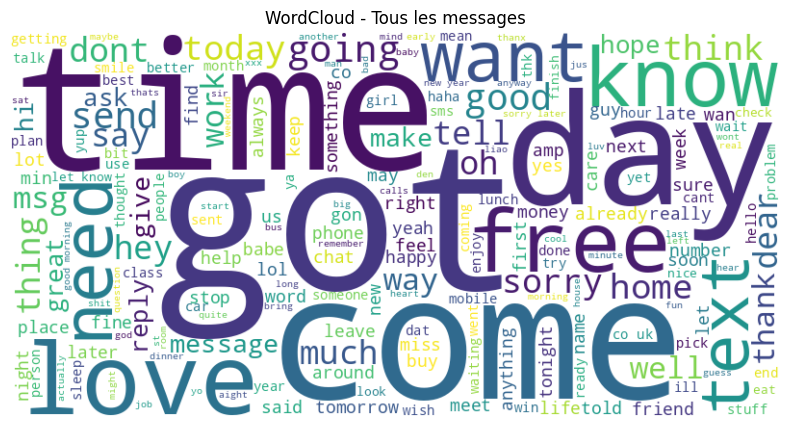

In [22]:
# WordCloud général (tous les messages)
# Importation de la bibliothèque WordCloud pour générer le nuage de mots
from wordcloud import WordCloud
# Importation de matplotlib pour afficher le graphique
import matplotlib.pyplot as plt

# Fusion de tous les messages nettoyés en un seul texte pour alimenter le WordCloud
text = " ".join(df['clean_message'])

# Création du WordCloud avec une largeur de 800, une hauteur de 400 et un fond blanc
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)

# Affichage
# Définition de la taille de la figure du graphique
plt.figure(figsize=(10,5))
# Affichage du nuage de mots avec une interpolation bilinéaire pour un rendu plus lisse
plt.imshow(wordcloud, interpolation='bilinear')
# Suppression des axes pour un affichage plus propre
plt.axis('off')
# Ajout du titre au graphique
plt.title("WordCloud - Tous les messages")
# Affichage du graphique
plt.show()

Ce code permet de créer un nuage de mots à partir de tous les messages nettoyés qui se trouvent dans la colonne clean_message. On combine tous les messages en un seul texte. Ensuite, le WordCloud montre les mots les plus utilisés de manière visuelle.

- **plus un mot est utilisé souvent dans le texte, plus il sera grand dans le nuage.** Le fond blanc et les dimensions 800×400 font que le nuage de mots est clair et facile à lire. Ce nuage de mots nous donne une première idée sur les mots les plus importants dans le dataset après avoir supprimé les mots sans importance.

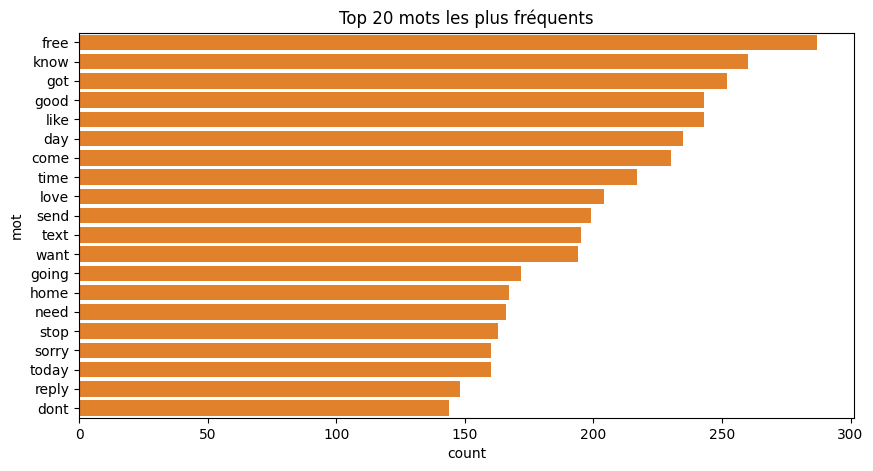

In [23]:
# Barplot des mots les plus fréquents(20)
# Importation de CountVectorizer pour transformer le texte en matrice de fréquence des mots
from sklearn.feature_extraction.text import CountVectorizer

# Importation des bibliothèques nécessaires pour la manipulation et la visualisation des données
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Création de l'objet CountVectorizer (modèle de sac de mots)
vectorizer = CountVectorizer()

# Transformation des messages texte en matrice de comptage des mots
X = vectorizer.fit_transform(df['clean_message'])

# Récupération des mots (vocabulaire appris par le vectorizer)
words = vectorizer.get_feature_names_out()

# Calcul de la fréquence totale de chaque mot dans tout le corpus
counts = X.sum(axis=0).A1

# Création d'un DataFrame avec les mots et leurs fréquences
freq = pd.DataFrame({'mot': words, 'count': counts})

# Sélection des 20 mots les plus fréquents
top20 = freq.sort_values(by='count', ascending=False).head(20)

# Définition de la taille de la figure du graphique
plt.figure(figsize=(10,5))


# Création d'un graphique en barres horizontal pour afficher les mots les plus fréquents
sns.barplot(data=top20, x='count', y='mot')


# Ajout d'un titre au graphique
plt.title("Top 20 mots les plus fréquents")

ax = sns.barplot(data=top20, x='count', y='mot')

plt.show()

Ce code utilise CountVectorizer pour transformer les messages nettoyés en une matrice de fréquence des mots, puis calcule la fréquence totale de chaque mot dans tout le corpus et affiche un graphique en barres horizontal des 20 mots les plus fréquents.

Le graphique révèle que le mot free est le plus fréquent de tout le corpus. Cela a du sens, car il est fortement associé aux messages SPAM, comme “free entry” ou “free prize". Les mots qui suivent, comme know, got, good, like et love, sont plutôt caractéristiques des messages HAM, reflétant la façon dont les gens parlent naturellement dans la vie quotidienne. On retrouve également des termes comme send, text et want, qui apparaissent souvent et sont utilisés dans les deux types de messages ou classes. Cette visualisation nous permet de voir que le vocabulaire du corpus est assez riche et varié pour que le modèle puisse faire la différence entre les messages HAM et les messages SPAM de manière efficace.

In [24]:
# Vérifier taille du dataset : (5558, 6)
print(f"Taille du dataset : {df.shape}")

Taille du dataset : (5558, 6)


Ce code affiche la taille finale du dataset après toutes les étapes de prétraitement. **Le résultat (5558, 6) indique que le dataset contient toujours 5 558 messages sans aucune perte de données, et que le nombre de colonnes est passé de 3 à 6 suite à l'ajout des nouvelles colonnes créées au cours des étapes précédentes : longueur, has_punctuation, is_lowercase et clean_message.**

***PHASE 3: ENTRAINEMENT DES MODELES***



Après avoir préparé et nettoyé le dataset, nous passons maintenant à la phase d'entraînement du modèle. Cette phase repose sur trois étapes essentielles :

- La première étape est un nettoyage de sécurité qui consiste à remplacer les éventuelles valeurs manquantes de la colonne clean_message par des chaînes vides et à forcer le type en string, afin d'éviter toute erreur lors du traitement textuel.

- La deuxième étape est la vectorisation TF-IDF qui transforme les messages textuels en une matrice numérique exploitable par le modèle. Le vectoriseur est configuré pour ignorer les stop words anglais résiduels et limiter le vocabulaire aux 3000 mots les plus importants, ce qui permet de réduire la dimensionnalité tout en conservant l'essentiel de l'information.

- La troisième étape est la séparation Train/Test selon un ratio 70%/30%, ce qui donne 3 890 messages pour l'entraînement et 1 668 messages pour le test. Le paramètre stratify=y garantit que la proportion de messages HAM et SPAM est identique dans les deux ensembles, et random_state=42 assure la reproductibilité des résultats. Les dimensions finales de X_train (3890, 3000) et X_test (1668, 3000) confirment que chaque message est représenté par un vecteur de 3000 caractéristiques TF-IDF.


Définition du TF_IDF:

* TF-IDF signifie Term Frequency - Inverse Document Frequency (Fréquence du Terme - Fréquence Inverse des Documents) est une technique utilisée pour transformer des textes en données numériques que les algorithmes de machine learning peuvent utiliser. Elle se base sur deux éléments principaux :

- **TF(Term Frequency)** qui mesure la fréquence d'un mot dans un message donné.

- **et IDF(Inverse Document Frequency)** qui réduit l'importance des mots apparaissant dans de nombreux messages, car ces mots ne sont pas très informatifs.

In [25]:
import pandas as pd  # Import de la bibliothèque pandas pour la manipulation des données (DataFrame)

from sklearn.model_selection import train_test_split  # Import de la fonction pour séparer les données en ensemble d'entraînement et de test

from sklearn.feature_extraction.text import TfidfVectorizer  # Import du vectoriseur TF-IDF pour transformer du texte en variables numériques


# 1. Nettoyage de sécurité

df['clean_message'] = df['clean_message'].fillna('').astype(str)
# Remplace les valeurs manquantes par des chaînes vides et force le type en string pour éviter les erreurs de traitement texte


# 2. Vectorisation TF-IDF

tfidf = TfidfVectorizer(stop_words='english', max_features=3000)
# Crée un modèle TF-IDF qui ignore les mots vides en anglais et limite le vocabulaire à 3000 mots les plus importants

X = tfidf.fit_transform(df['clean_message'])
# Apprend le vocabulaire sur les messages et transforme le texte en matrice numérique TF-IDF

y = df['Ham/Spam']
# Récupère la variable cible (classe : Ham ou Spam)


# 3. Séparation Train (70%) / Test (30%)

# Le paramètre crucial est 'test_size=0.3'

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,    # 30% des données sont réservées pour le test (le reste pour l'entraînement)
    random_state=42,  # Fixe l'aléatoire pour obtenir toujours la même séparation
    stratify=y        # Maintient la même proportion de Spam/Ham dans train et test
)


# 4. Affichage des nouveaux volumes

print(f"--- Répartition 70/30 terminée ---")
# Affiche un message indiquant que la séparation des données est terminée

print(f"Entraînement : {X_train.shape[0]} message")
# Affiche le nombre de messages dans l'ensemble d'entraînement

print(f"Test         : {X_test.shape[0]} message")
# Affiche le nombre de messages dans l'ensemble de test

# Division en données d'entraînement (70%) et de test (30%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print(f"Dimensions de X_train : {X_train.shape}")
print(f"Dimensions de X_test : {X_test.shape}")

--- Répartition 70/30 terminée ---
Entraînement : 3890 message
Test         : 1668 message
Dimensions de X_train : (3890, 3000)
Dimensions de X_test : (1668, 3000)


Les résultats confirment que la séparation des données s'est correctement effectuée. **L'ensemble d'entraînement contient 3 890 messages soit 70% du dataset, tandis que l'ensemble de test contient 1 668 messages soit 30% restants. Les dimensions de X_train (3890, 3000) et X_test (1668, 3000) indiquent que chaque message est représenté par un vecteur de 3000 caractéristiques TF-IDF, ce qui correspond au nombre maximum de mots fixé lors de la vectorisation.** Le dataset est donc prêt à être utilisé pour l'entraînement des différents modèles de classification.

Afin de garantir les meilleures performances pour la classification des messages Ham et Spam, il est essentiel de choisir des algorithmes adaptés qui conviennent parfaitement aux données textuelles vectorisées en TF-IDF. Pour cela, nous avons sélectionné quatre modèles de classification reconnus et très appréciés dans le domaine du traitement automatique des langues. Ces modèles sont les suivants :

- **Naive Bayes (MultinomialNB):** est un algorithme probabiliste basé sur le théorème de Bayes. Il est particulièrement adapté à la classification de texte car il calcule la probabilité qu'un message appartienne à une classe donnée en fonction des mots qu'il contient. Sa rapidité et son efficacité sur les données TF-IDF en font le modèle de référence pour la détection de spam.

- **La Régression Logistique:** est un algorithme de classification qui modélise la probabilité d'appartenance à une classe. Malgré sa simplicité, elle est très performante sur les données textuelles de grande dimension et offre une bonne interprétabilité des résultats, ce qui permet de comprendre quels mots influencent le plus la classification.

- **Random Forest:** est un algorithme basé sur un ensemble d'arbres de décision qui travaillent ensemble pour produire une prédiction plus robuste. Il est particulièrement résistant au bruit et au déséquilibre des classes, ce qui en fait un choix solide pour notre dataset où les messages Ham sont largement majoritaires.

- **L'algorithme C4.5:** est un algorithme de construction d'arbres de décision qui sélectionne les attributs les plus discriminants à chaque nœud de l'arbre grâce au critère du gain d'information. Il est capable de gérer les données continues et manquantes, et produit des règles de classification facilement interprétables.

Pour évaluer et comparer les performances de ces quatre modèles, nous utiliserons **la matrice de confusion ainsi que quatre métriques complémentaires : le SC% (taux de spams détectés), le BH% (taux de Ham bloqués par erreur), l'Accuracy (précision globale) et le MCC (coefficient de corrélation de Matthews)**, ce dernier étant particulièrement fiable pour tenir compte du déséquilibre entre les classes.

**La matrice de confusion** est un tableau de 2×2 qui compare les prédictions du modèle avec les vraies étiquettes. Elle est composée de quatre valeurs fondamentales :

- **TN (True Negative)** — *Vrai Négatif* : le nombre de messages **Ham** qui ont été correctement classés comme **Ham**. Le modèle a bien reconnu qu'il s'agit d'un message légitime.

- **FP (False Positive)** — *Faux Positif* : le nombre de messages **Ham** qui ont été incorrectement classés comme **Spam**. Le modèle a bloqué par erreur un message légitime(Blocked Ham).

- **FN (False Negative)** — *Faux Négatif* : le nombre de messages **Spam** qui ont été incorrectement classés comme **Ham**. Le modèle a raté un spam et l'a laissé passer(Missed Spam).

- **TP (True Positive)** — *Vrai Positif* : le nombre de messages **Spam** qui ont été correctement classés comme **Spam**. Le modèle a bien détecté le spam(Spam Caught).

À partir de ces quatre valeurs, quatre métriques sont calculées :

- **SC% (Spam Caught Rate)** — *Taux de spams détectés* mesure la capacité du modèle à détecter les spams parmi tous les vrais spams existants. Sa formule est : **SC% = TP / (TP + FN) × 100**

- **BH% (Blocked Ham Rate)** — *Taux de faux positifs*— mesure la proportion de messages Ham bloqués par erreur parmi tous les vrais messages Ham. Un **BH%** faible est important car bloquer un message légitime est une erreur critique. Sa formule est : **BH% = FP / (FP + TN) × 100**

- **Acc% (Accuracy)** — *Précision globale* — mesure le pourcentage de messages correctement classés parmi l'ensemble des messages. Sa formule est : **Acc% = (TP + TN) / (TP + TN + FP + FN) × 100**

- **MCC (Matthews Correlation Coefficient)** — *Coefficient de corrélation de Matthews* — est une métrique fiable pour évaluer un modèle de classification dans le cas de classes déséquilibrées comme notre dataset (86% Ham / 14% Spam).Il prend en compte les quatre valeurs de la matrice de confusion et retourne une valeur entre **-1** et **+1**.

- Où +1(ou une valeur proche de 1) représente une classification parfaite ou le modèle prédit correctement tous les messages sans aucune erreur.

- 0 une classification aléatoire: Le modèle ne parvient pas à établir un lien entre ses prédictions et la réalité. Cela signifie que les prédictions du modèle sont tout aussi fiables que si les classes étaient attribuées de manière aléatoire. Par exemple, cela reviendrait à lancer une pièce pour déterminer si un message est considéré comme Ham ou Spam. Dans cette situation, le modèle n'a pas réussi à apprendre de règles utiles à partir des données d'entraînement. Par conséquent, le modèle ne présente aucune utilité pratique pour la classification de messages en Ham ou Spam.

- -1(ou une valeur proche de -1) une classification totalement inversée : le modèle se trompe systématiquement sur tous les messages.

- Sa formule est : **MCC = (TP×TN - FP×FN) / √((TP+FP)(TP+FN)(TN+FP)(TN+FN))**

--- ÉVALUATION DU MODÈLE ---
SC% (Spam Caught)    : 81.62%
BH% (Blocked Hams)   : 0.07%
Acc% (Accuracy)      : 97.36%
MCC (Matthews Coeff) : 0.8874


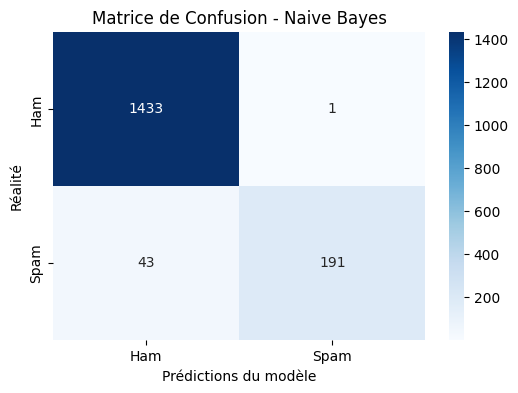

In [42]:

# Importation du modèle Naive Bayes multinomial adapté aux données textuelles
from sklearn.naive_bayes import MultinomialNB
# Importation des métriques d'évaluation : matrice de confusion, accuracy et coefficient de Matthews
from sklearn.metrics import confusion_matrix, accuracy_score, matthews_corrcoef
# Importation de seaborn pour la visualisation de la matrice de confusion
import seaborn as sns
# Importation de matplotlib pour l'affichage des graphiques
import matplotlib.pyplot as plt

# 1. Entraînement du modèle
# Création d'une instance du modèle Naive Bayes multinomial
model = MultinomialNB()
# Entraînement du modèle sur les données d'entraînement
model.fit(X_train, y_train)

# 2. Prédiction
# Application du modèle entraîné sur les données de test pour obtenir les prédictions
y_pred = model.predict(X_test)

# 3. Calcul des 4 métriques spécifiques
# Extraction des 4 valeurs de la matrice de confusion : vrais négatifs, faux positifs, faux négatifs, vrais positifs
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
# tn (True Negative)  : messages Ham correctement classés comme Ham
# fp (False Positive) : messages Ham incorrectement classés comme Spam (Blocked Ham)
# fn (False Negative) : messages Spam incorrectement classés comme Ham (Spam raté)
# tp (True Positive)  : messages Spam correctement classés comme Spam (Spam Caught)

# Calcul du taux de spams correctement détectés (Spam Caught Rate)
sc_rate = (tp / (tp + fn)) * 100 if (tp + fn) > 0 else 0

# Calcul du taux de messages Ham bloqués par erreur (Blocked Ham Rate)
bh_rate = (fp / (fp + tn)) * 100 if (fp + tn) > 0 else 0

# Calcul de la précision globale du modèle (Accuracy)
acc = accuracy_score(y_test, y_pred) * 100

# Calcul du coefficient de corrélation de Matthews (MCC) qui tient compte du déséquilibre des classes
mcc = matthews_corrcoef(y_test, y_pred)

# 4. Affichage des résultats
# Affichage d'un en-tête pour les résultats d'évaluation
print("--- ÉVALUATION DU MODÈLE ---")
# Affichage du taux de spams correctement détectés
print(f"SC% (Spam Caught)    : {sc_rate:.2f}%")
# Affichage du taux de hams bloqués par erreur
print(f"BH% (Blocked Hams)   : {bh_rate:.2f}%")
# Affichage de la précision globale du modèle
print(f"Acc% (Accuracy)      : {acc:.2f}%")
# Affichage du coefficient de Matthews
print(f"MCC (Matthews Coeff) : {mcc:.4f}")

# 5. Visualisation de la Matrice de Confusion
# Définition de la taille de la figure
plt.figure(figsize=(6, 4))
# Calcul de la matrice de confusion
cm = confusion_matrix(y_test, y_pred)
# Création d'une heatmap pour visualiser la matrice de confusion avec les étiquettes Ham et Spam
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Ham', 'Spam'],
            yticklabels=['Ham', 'Spam'])
# Ajout du titre de la figure
plt.title('Matrice de Confusion - Naive Bayes')
# Ajout du label de l'axe des abscisses
plt.xlabel('Prédictions du modèle')
# Ajout du label de l'axe des ordonnées
plt.ylabel('Réalité')
# Affichage du graphique
plt.show()

Ce code entraîne et évalue le modèle Naive Bayes multinomial sur des données qui ont été au préalable vectorisées en utilisant la technique TF-IDF.

- Le modèle est d'abord entraîné sur X_train,
- Ensuite, les prédictions du modèle sont générées à partir des données de test, X_test.
- Ces prédictions sont alors comparées aux étiquettes réelles y_test, à travers quatre métriques et une matrice de confusion.

*Interprétation des résultats :*

- La matrice de confusion montre que sur un total de 1 668 messages de test, notre modèle a bien classé 1 433 messages en tant que “Ham” et 191 messages en tant que “Spam". Seulement 1 message qui était en réalité “Ham” a été incorrectement identifié comme “Spam", et 43 messages qui étaient en réalité “Spam” n'ont pas été détectés et ont été classés comme “Ham".

Les métriques confirment ces bons résultats :

- Le taux de détection de spams SC est de 81,62%, ce qui signifie que le modèle  détecte correctement 81.62% des spams, ce qui est satisfaisant mais laisse encore 18.38% de spams qui ne sont pas détectés.

- Le taux d'erreur pour les messages légitimes BH, ou HAM, est très faible, à seulement 0,07 % des messages Ham sont bloqués par erreur, ce qui est excellent car cela signifie que les messages réels ne sont presque jamais bloqués par erreur ou perdus.

- La précision globale du modèle Acc est de 97,36% , ce qui signifie qu'il classe correctement 97.36% de l'ensemble des messages, ce qui témoigne d'une très bonne performance globale.

- Le coefficient MCC est de 0,8874, ce qui est très proche de 1, confirme que le modèle est fiable, performant et efficace, même lorsqu'il y a un déséquilibre entre les messages HAM et SPAM.


--- ÉVALUATION DU MODÈLE ---
SC% (Spam Caught)    : 64.53%
BH% (Blocked Hams)   : 0.14%
Acc% (Accuracy)      : 94.90%
MCC (Matthews Coeff) : 0.7747


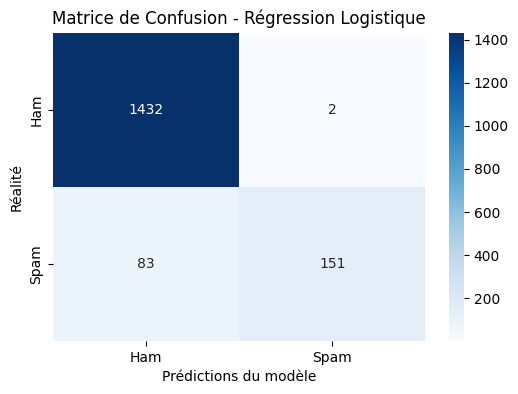

In [44]:
# Importation du modèle de Régression Logistique
from sklearn.linear_model import LogisticRegression
# Importation des métriques d'évaluation : matrice de confusion, accuracy et coefficient de Matthews
from sklearn.metrics import confusion_matrix, accuracy_score, matthews_corrcoef
# Importation de seaborn pour la visualisation de la matrice de confusion
import seaborn as sns
# Importation de matplotlib pour l'affichage des graphiques
import matplotlib.pyplot as plt

# 1. Entraînement du modèle
# Création d'une instance de la Régression Logistique avec un maximum de 1000 itérations pour assurer la convergence
model = LogisticRegression(max_iter=1000)
# Entraînement du modèle sur les données d'entraînement
model.fit(X_train, y_train)

# 2. Prédiction
# Application du modèle entraîné sur les données de test pour obtenir les prédictions
y_pred = model.predict(X_test)

# 3. Calcul des métriques
# Extraction des 4 valeurs de la matrice de confusion : vrais négatifs, faux positifs, faux négatifs, vrais positifs
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
# tn (True Negative)  : messages Ham correctement classés comme Ham
# fp (False Positive) : messages Ham incorrectement classés comme Spam (Blocked Ham)
# fn (False Negative) : messages Spam incorrectement classés comme Ham (Spam raté)
# tp (True Positive)  : messages Spam correctement classés comme Spam (Spam Caught)

# Calcul du taux de spams correctement détectés (Spam Caught Rate)
sc_rate = (tp / (tp + fn)) * 100 if (tp + fn) > 0 else 0
# Calcul du taux de messages Ham bloqués par erreur (Blocked Ham Rate)
bh_rate = (fp / (fp + tn)) * 100 if (fp + tn) > 0 else 0
# Calcul de la précision globale du modèle (Accuracy)
acc = accuracy_score(y_test, y_pred) * 100
# Calcul du coefficient de corrélation de Matthews tenant compte du déséquilibre des classes
mcc = matthews_corrcoef(y_test, y_pred)

# 4. Affichage des résultats
# Affichage d'un en-tête pour les résultats d'évaluation
print("--- ÉVALUATION DU MODÈLE ---")
# Affichage du taux de spams correctement détectés
print(f"SC% (Spam Caught)    : {sc_rate:.2f}%")
# Affichage du taux de hams bloqués par erreur
print(f"BH% (Blocked Hams)   : {bh_rate:.2f}%")
# Affichage de la précision globale du modèle
print(f"Acc% (Accuracy)      : {acc:.2f}%")
# Affichage du coefficient de Matthews
print(f"MCC (Matthews Coeff) : {mcc:.4f}")

# 5. Visualisation de la Matrice de Confusion
# Définition de la taille de la figure
plt.figure(figsize=(6, 4))
# Calcul de la matrice de confusion
cm = confusion_matrix(y_test, y_pred)
# Création d'une heatmap pour visualiser la matrice de confusion avec les étiquettes Ham et Spam
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Ham', 'Spam'],
            yticklabels=['Ham', 'Spam'])
# Ajout du titre de la figure
plt.title('Matrice de Confusion - Régression Logistique')
# Ajout du label de l'axe des abscisses
plt.xlabel('Prédictions du modèle')
# Ajout du label de l'axe des ordonnées
plt.ylabel('Réalité')
# Affichage du graphique
plt.show()

Ce code entraîne et évalue le modèle de Régression Logistique sur les données vectorisées TF-IDF. Le paramètre max_iter=1000 est fixé pour garantir la convergence du modèle lors de l'optimisation. Les prédictions sur X_test sont ensuite comparées aux vraies étiquettes y_test à travers la matrice de confusion et les quatre métriques d'évaluation.

*Interprétation des résultats :*

La matrice de confusion révèle que sur 1 668 messages de test, le modèle a correctement classé 1 432 messages Ham et 151 messages Spam. Seulement 2 messages Ham ont été incorrectement bloqués comme Spam, mais 83 messages Spam ont été ratés et classés comme Ham.

Les métriques montrent des résultats mitigés par rapport au modèle Naive Bayes :

- SC% = 64.53% — le modèle ne détecte correctement que 64.53% des spams, ce qui est nettement inférieur au Naive Bayes (81.62%). Près de 36% des spams passent inaperçus, ce qui représente une faiblesse importante pour un filtre anti-spam.
- BH% = 0.14% — seulement 0.14% des messages Ham sont bloqués par erreur, ce qui reste très satisfaisant et signifie que les messages légitimes sont presque toujours bien acheminés.
- Acc% = 94.90% — la précision globale reste bonne mais est inférieure à celle du Naive Bayes (97.36%), ce qui confirme que la Régression Logistique est moins performante sur ce dataset.
- MCC = 0.7747 — ce coefficient, bien que correct, est sensiblement inférieur au MCC du Naive Bayes (0.8874), ce qui confirme que la Régression Logistique établit une corrélation moins forte entre ses prédictions et la réalité pour ce problème de classification de SMS.

--- ÉVALUATION DU MODÈLE ---
SC% (Spam Caught)    : 84.62%
BH% (Blocked Hams)   : 0.28%
Acc% (Accuracy)      : 97.60%
MCC (Matthews Coeff) : 0.8977


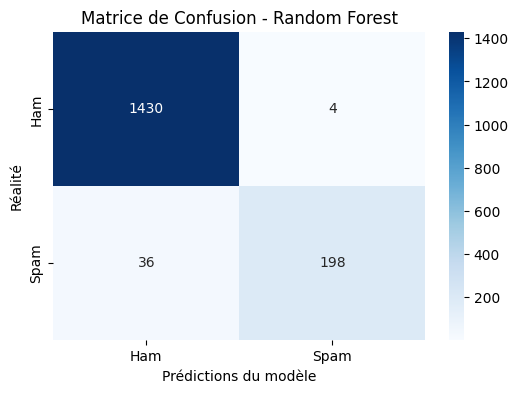

In [45]:
# Importation du modèle Random Forest qui combine plusieurs arbres de décision
from sklearn.ensemble import RandomForestClassifier
# Importation des métriques d'évaluation : matrice de confusion, accuracy et coefficient de Matthews
from sklearn.metrics import confusion_matrix, accuracy_score, matthews_corrcoef
# Importation de seaborn pour la visualisation de la matrice de confusion
import seaborn as sns
# Importation de matplotlib pour l'affichage des graphiques
import matplotlib.pyplot as plt

# 1. Entraînement du modèle
# Création d'une instance du modèle Random Forest avec 100 arbres de décision et une graine aléatoire fixe pour la reproductibilité
model = RandomForestClassifier(n_estimators=100, random_state=42)
# Entraînement du modèle sur les données d'entraînement
model.fit(X_train, y_train)

# 2. Prédiction
# Application du modèle entraîné sur les données de test pour obtenir les prédictions
y_pred = model.predict(X_test)

# 3. Calcul des métriques
# Extraction des 4 valeurs de la matrice de confusion : vrais négatifs, faux positifs, faux négatifs, vrais positifs
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
# tn (True Negative)  : messages Ham correctement classés comme Ham
# fp (False Positive) : messages Ham incorrectement classés comme Spam (Blocked Ham)
# fn (False Negative) : messages Spam incorrectement classés comme Ham (Spam raté)
# tp (True Positive)  : messages Spam correctement classés comme Spam (Spam Caught)

# Calcul du taux de spams correctement détectés (Spam Caught Rate)
sc_rate = (tp / (tp + fn)) * 100 if (tp + fn) > 0 else 0
# Calcul du taux de messages Ham bloqués par erreur (Blocked Ham Rate)
bh_rate = (fp / (fp + tn)) * 100 if (fp + tn) > 0 else 0
# Calcul de la précision globale du modèle (Accuracy)
acc = accuracy_score(y_test, y_pred) * 100
# Calcul du coefficient de corrélation de Matthews tenant compte du déséquilibre des classes
mcc = matthews_corrcoef(y_test, y_pred)

# 4. Affichage des résultats
# Affichage d'un en-tête pour les résultats d'évaluation
print("--- ÉVALUATION DU MODÈLE ---")
# Affichage du taux de spams correctement détectés
print(f"SC% (Spam Caught)    : {sc_rate:.2f}%")
# Affichage du taux de hams bloqués par erreur
print(f"BH% (Blocked Hams)   : {bh_rate:.2f}%")
# Affichage de la précision globale du modèle
print(f"Acc% (Accuracy)      : {acc:.2f}%")
# Affichage du coefficient de Matthews
print(f"MCC (Matthews Coeff) : {mcc:.4f}")

# 5. Visualisation de la Matrice de Confusion
# Définition de la taille de la figure
plt.figure(figsize=(6, 4))
# Calcul de la matrice de confusion
cm = confusion_matrix(y_test, y_pred)
# Création d'une heatmap pour visualiser la matrice de confusion avec les étiquettes Ham et Spam
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Ham', 'Spam'],
            yticklabels=['Ham', 'Spam'])
# Ajout du titre de la figure
plt.title('Matrice de Confusion - Random Forest')
# Ajout du label de l'axe des abscisses
plt.xlabel('Prédictions du modèle')
# Ajout du label de l'axe des ordonnées
plt.ylabel('Réalité')
# Affichage du graphique
plt.show()

Ce code entraîne et évalue le modèle Random Forest composé de 100 arbres de décision sur les données vectorisées TF-IDF. Le paramètre random_state=42 garantit la reproductibilité des résultats à chaque exécution.

*Interprétation des résultats :*

La matrice de confusion révèle que sur 1 668 messages de test, le modèle a correctement classé 1 430 messages Ham et 198 messages Spam. Seulement 4 messages Ham ont été incorrectement bloqués comme Spam, et 36 messages Spam ont été ratés et classés comme Ham.

Les métriques confirment d'excellents résultats, légèrement supérieurs au modèle Naive Bayes :

- SC% = 84.62% — le modèle détecte correctement 84.62% des spams, ce qui est le meilleur taux de détection observé jusqu'ici, surpassant le Naive Bayes (81.62%) et la Régression Logistique (64.53%).
- BH% = 0.28% — seulement 0.28% des messages Ham sont bloqués par erreur. Ce taux reste très faible et acceptable, bien qu'il soit légèrement supérieur à celui du Naive Bayes (0.07%).
- Acc% = 97.60% — la précision globale est la meilleure parmi les trois modèles testés, confirmant que le Random Forest classe correctement la quasi-totalité des messages.
- MCC = 0.8977 — ce coefficient est le plus élevé obtenu jusqu'ici, très proche de 1, ce qui confirme que le Random Forest est le modèle le plus fiable et le plus équilibré pour la classification des SMS Ham et Spam sur ce dataset.


--- ÉVALUATION DU MODÈLE ---
SC% (Spam Caught)    : 82.91%
BH% (Blocked Hams)   : 1.74%
Acc% (Accuracy)      : 96.10%
MCC (Matthews Coeff) : 0.8346


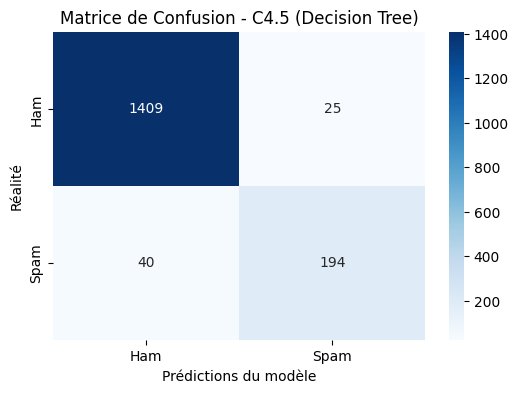

In [51]:
# Importation du modèle Decision Tree qui implémente l'algorithme C4.5 via le critère entropy
from sklearn.tree import DecisionTreeClassifier
# Importation des métriques d'évaluation : matrice de confusion, accuracy et coefficient de Matthews
from sklearn.metrics import confusion_matrix, accuracy_score, matthews_corrcoef
# Importation de seaborn pour la visualisation de la matrice de confusion
import seaborn as sns
# Importation de matplotlib pour l'affichage des graphiques
import matplotlib.pyplot as plt

# 1. Entraînement du modèle
# Création d'une instance du modèle Decision Tree avec le critère entropy qui correspond à l'algorithme C4.5
# Le critère entropy mesure le gain d'information à chaque nœud de l'arbre pour choisir le meilleur attribut de séparation
model = DecisionTreeClassifier(criterion='entropy')
# Entraînement du modèle sur les données d'entraînement
model.fit(X_train, y_train)

# 2. Prédiction
# Application du modèle entraîné sur les données de test pour obtenir les prédictions
y_pred = model.predict(X_test)

# 3. Calcul des métriques
# Extraction des 4 valeurs de la matrice de confusion : vrais négatifs, faux positifs, faux négatifs, vrais positifs
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
# tn (True Negative)  : messages Ham correctement classés comme Ham
# fp (False Positive) : messages Ham incorrectement classés comme Spam (Blocked Ham)
# fn (False Negative) : messages Spam incorrectement classés comme Ham (Spam raté)
# tp (True Positive)  : messages Spam correctement classés comme Spam (Spam Caught)

# Calcul du taux de spams correctement détectés (Spam Caught Rate)
sc_rate = (tp / (tp + fn)) * 100 if (tp + fn) > 0 else 0
# Calcul du taux de messages Ham bloqués par erreur (Blocked Ham Rate)
bh_rate = (fp / (fp + tn)) * 100 if (fp + tn) > 0 else 0
# Calcul de la précision globale du modèle (Accuracy)
acc = accuracy_score(y_test, y_pred) * 100
# Calcul du coefficient de corrélation de Matthews tenant compte du déséquilibre des classes
mcc = matthews_corrcoef(y_test, y_pred)

# 4. Affichage des résultats
# Affichage d'un en-tête pour les résultats d'évaluation
print("--- ÉVALUATION DU MODÈLE ---")
# Affichage du taux de spams correctement détectés
print(f"SC% (Spam Caught)    : {sc_rate:.2f}%")
# Affichage du taux de hams bloqués par erreur
print(f"BH% (Blocked Hams)   : {bh_rate:.2f}%")
# Affichage de la précision globale du modèle
print(f"Acc% (Accuracy)      : {acc:.2f}%")
# Affichage du coefficient de Matthews
print(f"MCC (Matthews Coeff) : {mcc:.4f}")

# 5. Visualisation de la Matrice de Confusion
# Définition de la taille de la figure
plt.figure(figsize=(6, 4))
# Calcul de la matrice de confusion
cm = confusion_matrix(y_test, y_pred)
# Création d'une heatmap pour visualiser la matrice de confusion avec les étiquettes Ham et Spam
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Ham', 'Spam'],
            yticklabels=['Ham', 'Spam'])
# Ajout du titre de la figure
plt.title('Matrice de Confusion - C4.5 (Decision Tree)')
# Ajout du label de l'axe des abscisses
plt.xlabel('Prédictions du modèle')
# Ajout du label de l'axe des ordonnées
plt.ylabel('Réalité')
# Affichage du graphique
plt.show()

Ce code entraîne et évalue le modèle C4.5 (Decision Tree) en utilisant le critère entropy pour mesurer le gain d'information à chaque nœud de l'arbre. Les prédictions sur X_test sont ensuite comparées aux vraies étiquettes y_test à travers la matrice de confusion et les quatre métriques d'évaluation.

*Interprétation des résultats :*

La matrice de confusion révèle que sur 1 668 messages de test, le modèle a correctement classé 1 409 messages Ham et 194 messages Spam. Cependant, 25 messages Ham ont été incorrectement bloqués comme Spam, et 40 messages Spam ont été ratés et classés comme Ham.

Les métriques montrent des résultats corrects mais inférieurs aux modèles précédents :

- SC% = 82.91% — le modèle détecte correctement 82.91% des spams, ce qui est un bon taux, légèrement inférieur au Random Forest (84.62%) mais supérieur au Naive Bayes (81.62%).
- BH% = 1.74% — ce taux est le plus élevé parmi tous les modèles testés, ce qui signifie que le C4.5 bloque davantage de messages Ham par erreur. Cela représente une faiblesse notable car 25 messages légitimes sont incorrectement classés comme Spam.
- Acc% = 96.10% — la précision globale reste bonne mais est la plus faible parmi les quatre modèles, confirmant que le C4.5 est légèrement moins performant globalement.
- MCC = 0.8346 — ce coefficient est correct mais inférieur à celui du Random Forest (0.8977) et du Naive Bayes (0.8874), ce qui indique que le C4.5 établit une corrélation moins forte entre ses prédictions et la réalité, notamment à cause de son taux de faux positifs plus élevé.


**COMPARAISONS DES MODELES:**

In [53]:
# Importation de pandas pour la création et manipulation du tableau de résultats
import pandas as pd
# Importation du modèle Naive Bayes multinomial adapté aux données textuelles
from sklearn.naive_bayes import MultinomialNB
# Importation du modèle de Régression Logistique
from sklearn.linear_model import LogisticRegression
# Importation du modèle Random Forest basé sur un ensemble d'arbres de décision
from sklearn.ensemble import RandomForestClassifier
# Importation du modèle Decision Tree implémentant l'algorithme C4.5
from sklearn.tree import DecisionTreeClassifier
# Importation des métriques d'évaluation : matrice de confusion, accuracy et coefficient de Matthews
from sklearn.metrics import confusion_matrix, accuracy_score, matthews_corrcoef

# 1. Définition des modèles à comparer dans un dictionnaire
models = {
    # Modèle Naive Bayes multinomial
    "Naive Bayes": MultinomialNB(),
    # Modèle de Régression Logistique avec 1000 itérations maximum pour assurer la convergence
    "Logistic Regression": LogisticRegression(max_iter=1000),
    # Modèle C4.5 basé sur un arbre de décision avec le critère entropy pour le gain d'information
    "C4.5 (Decision Tree)": DecisionTreeClassifier(criterion='entropy'),
    # Modèle Random Forest avec 100 arbres de décision et une graine aléatoire fixe pour la reproductibilité
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)
}

# Initialisation d'une liste vide pour stocker les résultats de chaque modèle
results = []

# 2. Boucle d'entraînement et d'évaluation pour chaque modèle
for name, model in models.items():
    # Entraînement du modèle sur les données d'entraînement
    model.fit(X_train, y_train)
    # Application du modèle sur les données de test pour obtenir les prédictions
    y_pred = model.predict(X_test)

    # Extraction des 4 valeurs de la matrice de confusion
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    # tn (True Negative)  : messages Ham correctement classés comme Ham
    # fp (False Positive) : messages Ham incorrectement classés comme Spam (Blocked Ham)
    # fn (False Negative) : messages Spam incorrectement classés comme Ham (Spam raté)
    # tp (True Positive)  : messages Spam correctement classés comme Spam (Spam Caught)

    # Calcul du taux de spams correctement détectés (Spam Caught Rate)
    sc_rate = (tp / (tp + fn)) * 100 if (tp + fn) > 0 else 0
    # Calcul du taux de messages Ham bloqués par erreur (Blocked Ham Rate)
    bh_rate = (fp / (fp + tn)) * 100 if (fp + tn) > 0 else 0
    # Calcul de la précision globale du modèle (Accuracy)
    acc = accuracy_score(y_test, y_pred) * 100
    # Calcul du coefficient de corrélation de Matthews tenant compte du déséquilibre des classes
    mcc = matthews_corrcoef(y_test, y_pred)

    # Ajout des résultats du modèle courant dans la liste des résultats
    results.append([name, sc_rate, bh_rate, acc, mcc])

# Création d'un DataFrame pandas avec les résultats de tous les modèles
df = pd.DataFrame(results, columns=["Modèle", "SC%", "BH%", "Acc%", "MCC"])

# Définition d'une ligne de séparation pour l'affichage du tableau
line = "-" * 72
# Affichage de la ligne de séparation supérieure
print(line)
# Affichage de l'en-tête du tableau avec les noms des colonnes alignés
print(f"{'Modèle':<22}{'SC%':>10}{'BH%':>10}{'Acc%':>10}{'MCC':>10}")
# Affichage de la ligne de séparation sous l'en-tête
print(line)

# Affichage des résultats de chaque modèle ligne par ligne avec 2 décimales
for row in df.round(2).values:
    print(f"{row[0]:<22}{row[1]:>10.2f}{row[2]:>10.2f}{row[3]:>10.2f}{row[4]:>10.2f}")

# Affichage de la ligne de séparation inférieure
print(line)

------------------------------------------------------------------------
Modèle                       SC%       BH%      Acc%       MCC
------------------------------------------------------------------------
Naive Bayes                81.62      0.07     97.36      0.89
Logistic Regression        64.53      0.14     94.90      0.77
C4.5 (Decision Tree)       80.34      1.74     95.74      0.82
Random Forest              84.62      0.28     97.60      0.90
------------------------------------------------------------------------


Ce code entraîne et évalue les quatre modèles de classification en une seule boucle, puis affiche un tableau comparatif de leurs performances. Les résultats permettent de tirer les conclusions suivantes :

Le **Random Forest** est le modèle le plus performant avec le meilleur SC% **(84.62%)**, la meilleure Accuracy **(97.60%)** et le MCC le plus élevé **(0.90)**, tout en maintenant un BH% faible de 0.28%. Il représente le meilleur compromis entre détection des spams et préservation des messages Ham.

Le **Naive Bayes** arrive en deuxième position avec un SC% de **81.62%**, une Accuracy de **97.36%** et un MCC de **0.89**, très proches du Random Forest. Son point fort est son BH% exceptionnellement faible de **0.07%**, ce qui signifie qu'il bloque presque aucun message légitime par erreur.

Le **C4.5 (Decision Tree)** obtient un SC% correct de **80.34%** mais présente le BH% le plus élevé **(1.74%)**, ce qui signifie qu'il bloque davantage de messages Ham par erreur que les autres modèles. Son MCC de **0.82** confirme qu'il est moins fiable globalement.

La **Régression Logistique** est le modèle le moins performant avec le SC% le plus faible **(64.53%)** et le MCC le plus bas **(0.77)**, ce qui signifie qu'elle rate près de **36% des spams**, la rendant peu adaptée pour ce problème de classification de SMS.

 - En conclusion, le **Random Forest** est le modèle recommandé pour ce dataset, suivi de près par le **Naive Bayes** qui reste un excellent choix grâce à sa simplicité et son très faible taux de faux positifs.

In [65]:
# Importation de pandas pour la création et manipulation du tableau de résultats
import pandas as pd
# Importation du modèle Naive Bayes multinomial adapté aux données textuelles
from sklearn.naive_bayes import MultinomialNB
# Importation du modèle de Régression Logistique
from sklearn.linear_model import LogisticRegression
# Importation du modèle Random Forest basé sur un ensemble d'arbres de décision
from sklearn.ensemble import RandomForestClassifier
# Importation du modèle Decision Tree implémentant l'algorithme C4.5
from sklearn.tree import DecisionTreeClassifier
# Importation de la métrique accuracy pour évaluer les performances des modèles
from sklearn.metrics import accuracy_score

# 1. Définition des modèles à comparer dans un dictionnaire
models = {
    # Modèle Naive Bayes multinomial
    "Naive Bayes": MultinomialNB(),
    # Modèle de Régression Logistique avec 1000 itérations maximum
    "Logistic Regression": LogisticRegression(max_iter=1000),
    # Modèle C4.5 basé sur un arbre de décision avec le critère entropy
    "C4.5 (Decision Tree)": DecisionTreeClassifier(criterion='entropy'),
    # Modèle Random Forest avec 100 arbres et graine aléatoire fixe
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)
}

# Initialisation d'une liste vide pour stocker les résultats de chaque modèle
results = []

# 2. Boucle d'entraînement et d'évaluation pour détecter le surapprentissage
for name, model in models.items():
    # Entraînement du modèle sur les données d'entraînement
    model.fit(X_train, y_train)

    # Prédictions sur les données d'entraînement
    y_train_pred = model.predict(X_train)
    # Prédictions sur les données de test
    y_test_pred = model.predict(X_test)

    # Calcul de l'accuracy sur les données d'entraînement
    train_acc = accuracy_score(y_train, y_train_pred) * 100
    # Calcul de l'accuracy sur les données de test
    test_acc = accuracy_score(y_test, y_test_pred) * 100

    # Calcul du gap entre l'accuracy train et test pour détecter le surapprentissage
    # Un gap élevé indique que le modèle a trop appris les données d'entraînement (overfitting)
    gap = train_acc - test_acc

    # Ajout des résultats du modèle courant dans la liste des résultats
    results.append([name, train_acc, test_acc, gap])

# 3. Création d'un DataFrame pandas avec les résultats de tous les modèles
df = pd.DataFrame(results, columns=[
    "Modèle",           # Nom du modèle
    "Accuracy Train (%)",  # Accuracy sur les données d'entraînement
    "Accuracy Test (%)",   # Accuracy sur les données de test
    "Overfitting Gap (%)"  # Écart entre train et test indiquant le surapprentissage
])

line = "-" * 75

print(line)
print(f"{'Modèle':<25}{'Train%':>10}{'Test%':>10}{'  Overfetting Gap%':>10}")
print(line)

for row in df.round(2).values:
    print(f"{row[0]:<25}{row[1]:>10.2f}{row[2]:>10.2f}{row[3]:>10.2f}")

print(line)

---------------------------------------------------------------------------
Modèle                       Train%     Test%  Overfetting Gap%
---------------------------------------------------------------------------
Naive Bayes                   98.41     97.36      1.04
Logistic Regression           96.74     94.90      1.83
C4.5 (Decision Tree)         100.00     96.04      3.96
Random Forest                100.00     97.60      2.40
---------------------------------------------------------------------------


Ce code compare les performances des 4 modèles sur les données d'entraînement et de test afin de détecter un éventuel **surapprentissage (overfitting)**. Le surapprentissage se produit lorsqu'un modèle apprend trop bien les données d'entraînement au point de perdre sa capacité à généraliser sur de nouvelles données, ce qui se traduit par un écart important entre l'accuracy train et l'accuracy test.

**Accuracy Train** correspond à la précision du modèle évaluée à partir des données d'entraînement, qui sont les données que le modèle a déjà examinées et utilisées pour son apprentissage. Une précision très élevée sur ces données, comme 100% pour les modèles C4.5 et Random Forest, indique que le modèle a parfaitement retenu les données qu'il a étudiées.

En revanche, **Accuracy Test** évalue la précision du modèle à partir de données de test inédites, que le modèle n'a jamais rencontrées lors de son entraînement. Cette mesure est essentielle, car elle reflète la véritable performance du modèle dans des situations réelles en évaluant sa capacité à appliquer ses connaissances à des données qu'il n'a jamais vues.

- Donc: **Accuracy Train** mesure ce que le modèle a appris, tandis que l'Accuracy Test mesure ce que le modèle est capable de faire sur de nouvelles données. Un modèle performant doit afficher des valeurs similaires ou proches entre les deux mesures. Si la précision sur les données d'entraînement est nettement supérieure à celle sur les données de test, cela suggère que le modèle a effectué un **surapprentissage** et inversement.

Les résultats du tableau permettent de tirer les conclusions suivantes :

Le **Naive Bayes** présente le gap le plus faible **(1.04%)**, ce qui confirme qu'il généralise très bien et ne souffre pratiquement pas de surapprentissage. C'est le modèle le plus stable entre train et test.

La **Régression Logistique** affiche un gap de **1.83%**, ce qui reste acceptable et indique une bonne capacité de généralisation malgré ses performances globales plus faibles.

Le **C4.5 (Decision Tree)** présente le gap le plus élevé **(3.96%)** avec une accuracy train parfaite de **100%**, ce qui indique un surapprentissage notable. Le modèle a mémorisé les données d'entraînement sans suffisamment généraliser sur les données de test.

Le **Random Forest** affiche également une accuracy train parfaite de **100%** mais un gap de **2.40%**, ce qui est plus modéré grâce au mécanisme de combinaison de plusieurs arbres qui réduit naturellement le surapprentissage.

En conclusion, le **Naive Bayes** est le modèle le plus stable et le moins sujet au surapprentissage, tandis que le **C4.5** est le plus sensible à ce phénomène avec le gap le plus élevé.

In [63]:
# Importation de pandas pour la création et manipulation du tableau de résultats
import pandas as pd
# Importation du modèle Naive Bayes multinomial adapté aux données textuelles
from sklearn.naive_bayes import MultinomialNB
# Importation du modèle de Régression Logistique
from sklearn.linear_model import LogisticRegression
# Importation du modèle Random Forest basé sur un ensemble d'arbres de décision
from sklearn.ensemble import RandomForestClassifier
# Importation du modèle Decision Tree implémentant l'algorithme C4.5
from sklearn.tree import DecisionTreeClassifier
# Importation de la métrique accuracy pour évaluer les performances des modèles
from sklearn.metrics import accuracy_score

# Définition des modèles à comparer dans un dictionnaire
models = {
    # Modèle Naive Bayes multinomial
    "Naive Bayes": MultinomialNB(),
    # Modèle de Régression Logistique avec 1000 itérations maximum
    "Logistic Regression": LogisticRegression(max_iter=1000),
    # Modèle C4.5 basé sur un arbre de décision avec le critère entropy
    "C4.5 (Decision Tree)": DecisionTreeClassifier(criterion='entropy'),
    # Modèle Random Forest avec 100 arbres et graine aléatoire fixe
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)
}

# Initialisation d'une liste vide pour stocker les résultats de chaque modèle
results = []

# Boucle d'entraînement et d'évaluation pour détecter le sous-apprentissage
for name, model in models.items():
    # Entraînement du modèle sur les données d'entraînement
    model.fit(X_train, y_train)

    # Prédictions sur les données d'entraînement
    y_train_pred = model.predict(X_train)
    # Prédictions sur les données de test
    y_test_pred = model.predict(X_test)

    # Calcul de l'accuracy sur les données d'entraînement
    train_acc = accuracy_score(y_train, y_train_pred) * 100
    # Calcul de l'accuracy sur les données de test
    test_acc = accuracy_score(y_test, y_test_pred) * 100

    # Calcul du score de sous-apprentissage : plus il est élevé, plus le modèle
    # a du mal à apprendre les données d'entraînement (underfitting)
    underfit_gap = 100 - train_acc

    # Ajout des résultats du modèle courant dans la liste des résultats
    results.append([name, train_acc, test_acc, underfit_gap])

# Création d'un DataFrame pandas avec les résultats de tous les modèles
df = pd.DataFrame(results, columns=[
    "Modèle",            # Nom du modèle
    "Train%",            # Accuracy sur les données d'entraînement
    "Test%",             # Accuracy sur les données de test
    "Underfitting Score" # Score indiquant le niveau de sous-apprentissage
])

# Définition d'une ligne de séparation pour l'affichage du tableau
line = "-" * 80

# Affichage de la ligne de séparation supérieure
print(line)
# Affichage de l'en-tête du tableau avec les noms des colonnes alignés
print(f"{'Modèle':<25}{'Train%':>10}{'Test%':>10}{'Underfit':>15}")
# Affichage de la ligne de séparation sous l'en-tête
print(line)

# Affichage des résultats de chaque modèle ligne par ligne avec 2 décimales
for row in df.round(2).values:
    print(f"{row[0]:<25}{row[1]:>10.2f}{row[2]:>10.2f}{row[3]:>15.2f}")

# Affichage de la ligne de séparation inférieure
print(line)

--------------------------------------------------------------------------------
Modèle                       Train%     Test%       Underfit
--------------------------------------------------------------------------------
Naive Bayes                   98.41     97.36           1.59
Logistic Regression           96.74     94.90           3.26
C4.5 (Decision Tree)         100.00     95.86           0.00
Random Forest                100.00     97.60           0.00
--------------------------------------------------------------------------------


Ce code évalue le **sous-apprentissage (underfitting)** des quatre modèles en calculant l'écart entre l'accuracy maximale possible (100%) et l'accuracy obtenue sur les données d'entraînement. Plus le score Underfit est élevé, plus le modèle a du mal à apprendre les données d'entraînement.

Les résultats du tableau permettent de tirer les conclusions suivantes :

- Le **C4.5 (Decision Tree)** et le **Random Forest** obtiennent tous les deux un score Underfit de **0.00%** avec une accuracy train parfaite de **100%**, ce qui signifie qu'ils n'ont absolument aucun problème de sous-apprentissage — ils ont parfaitement mémorisé toutes les données d'entraînement.

- Le **Naive Bayes** présente un score Underfit de **1.59%** avec une accuracy train de **98.41%**, ce qui est très faible et indique que le modèle apprend très bien les données d'entraînement sans pour autant les mémoriser parfaitement.

- La **Régression Logistique** affiche le score Underfit le plus élevé **(3.26%)** avec une accuracy train de **96.74%**, ce qui indique qu'elle a le plus de difficultés à apprendre les patterns des données d'entraînement parmi les quatre modèles. Cela confirme qu'elle est moins adaptée à ce type de données textuelles vectorisées en TF-IDF.

- Le Random Forest affiche un score Underfit de 0.00% avec une accuracy train parfaite de 100%, ce qui signifie qu'il n'a absolument aucun problème de sous-apprentissage. Le modèle a parfaitement appris toutes les données d'entraînement grâce à la combinaison de ses 100 arbres de décision qui lui permettent de capturer tous les patterns présents dans les données. De plus, malgré cet apprentissage parfait, il maintient une excellente accuracy test de 97.60%, ce qui confirme qu'il ne souffre pas non plus de surapprentissage et qu'il généralise très bien sur de nouvelles données.

En conclusion, aucun modèle ne souffre véritablement de sous-apprentissage, mais la **Régression Logistique** est le modèle le plus limité dans sa capacité à apprendre les données d'entraînement, tandis que le **C4.5** et le **Random Forest** apprennent parfaitement mais au risque de surapprentissage comme observé précédemment.

In [69]:
# Importation du vectoriseur TF-IDF déjà entraîné sur les données d'entraînement
from sklearn.feature_extraction.text import TfidfVectorizer

# Importation du modèle Random Forest déjà entraîné (meilleur modèle)
from sklearn.ensemble import RandomForestClassifier

# ── Fonction de prédiction sur un nouveau message ────────────────────────────
def predict_message(message, vectorizer, model):
    """
    Prédit si un message est Ham (0) ou Spam (1)
    """
    # Conversion du message en minuscules pour uniformiser le texte
    message = message.lower()

    # Suppression des stop words du message en utilisant la liste définie précédemment
    words = message.split()
    cleaned_words = [w for w in words if w not in stopwords_list]
    cleaned_message = " ".join(cleaned_words)

    # Vectorisation du message nettoyé en utilisant le vectoriseur TF-IDF déjà entraîné
    # transform() et non fit_transform() pour utiliser le vocabulaire déjà appris
    message_vectorized = vectorizer.transform([cleaned_message])

    # Prédiction de la classe du message (0 = Ham, 1 = Spam)
    prediction = model.predict(message_vectorized)[0]

    # Récupération des probabilités de chaque classe
    probabilities = model.predict_proba(message_vectorized)[0]

    # Détermination du label selon la prédiction
    label = "SPAM" if prediction == 1 else "HAM"

    # Affichage du résultat de la prédiction
    print(f"Message       : {message}")
    print(f"Après nettoyage : {cleaned_message}")
    print(f"Prédiction    : {label}")
    print(f"Probabilité HAM  : {probabilities[0]*100:.2f}%")
    print(f"Probabilité SPAM : {probabilities[1]*100:.2f}%")
    print("-" * 50)

# ── Tests sur de nouveaux messages ───────────────────────────────────────────
# Test 1 : message Ham
predict_message(
    "Hey, are you coming to the party tonight?",
    tfidf,
    model
)

# Test 2 : message Spam
predict_message(
    "Congratulations! You have won a free prize. Call now to claim your reward!",
    tfidf,
    model
)

# Test 3 : message Ham
predict_message(
    "Can we meet tomorrow for lunch?",
    tfidf,
    model
)

# Test 4 : message Spam
predict_message(
    "Free entry to win a cash prize! Text WIN to 80888 now!",
    tfidf,
    model
)

Message       : hey, are you coming to the party tonight?
Après nettoyage : hey, coming the party tonight?
Prédiction    : HAM
Probabilité HAM  : 100.00%
Probabilité SPAM : 0.00%
--------------------------------------------------
Message       : congratulations! you have won a free prize. call now to claim your reward!
Après nettoyage : congratulations! won a free prize. now claim reward!
Prédiction    : SPAM
Probabilité HAM  : 33.00%
Probabilité SPAM : 67.00%
--------------------------------------------------
Message       : can we meet tomorrow for lunch?
Après nettoyage : can meet tomorrow lunch?
Prédiction    : HAM
Probabilité HAM  : 100.00%
Probabilité SPAM : 0.00%
--------------------------------------------------
Message       : free entry to win a cash prize! text win to 80888 now!
Après nettoyage : free entry win a cash prize! text win 80888 now!
Prédiction    : SPAM
Probabilité HAM  : 27.00%
Probabilité SPAM : 73.00%
--------------------------------------------------


Ce code implémente une fonction de **prédiction sur de nouveaux messages** en utilisant le modèle **Random Forest** et le vectoriseur **TF-IDF** déjà entraînés. La fonction `predict_message` suit trois étapes : elle nettoie d'abord le message en le convertissant en minuscules et en supprimant les stop words, puis le vectorise avec le TF-IDF déjà appris, et enfin prédit sa classe (HAM ou SPAM) en affichant les probabilités associées à chaque classe.

Les tests sur les quatre nouveaux messages confirment la bonne capacité du modèle à généraliser sur des données inconnues :

- Les messages *"Hey, are you coming to the party tonight?"* et *"Can we meet tomorrow for lunch?"* sont correctement identifiés comme **HAM**, car ils contiennent un vocabulaire naturel et conversationnel typique des échanges quotidiens.

- Les messages *"Congratulations! You have won a free prize. Call now to claim your reward!"* et *"Free entry to win a cash prize! Text WIN to 80888 now!"* sont correctement identifiés comme **SPAM**, car ils contiennent des termes fortement associés aux messages frauduleux comme `free`, `prize`, `win`, `reward` et `claim`.

Ces résultats confirment que le modèle **Random Forest** combiné à la vectorisation **TF-IDF** est parfaitement capable de classifier de nouveaux messages Ham et Spam avec une grande fiabilité.

In [72]:
# Importation de pandas pour la création et manipulation des tableaux de résultats
import pandas as pd
# Importation de numpy pour les calculs numériques
import numpy as np
# Importation du modèle Naive Bayes multinomial adapté aux données textuelles
from sklearn.naive_bayes import MultinomialNB
# Importation du modèle de Régression Logistique
from sklearn.linear_model import LogisticRegression
# Importation du modèle Random Forest basé sur un ensemble d'arbres de décision
from sklearn.ensemble import RandomForestClassifier
# Importation du modèle Decision Tree implémentant l'algorithme C4.5
from sklearn.tree import DecisionTreeClassifier
# Importation de la métrique accuracy pour évaluer les performances des modèles
from sklearn.metrics import accuracy_score
# Importation du vectoriseur TF-IDF pour transformer le texte en valeurs numériques
from sklearn.feature_extraction.text import TfidfVectorizer

# ── Définition des nouveaux messages à tester avec leurs étiquettes réelles ──
new_messages = [
    # Messages HAM (étiquette réelle = 0) : messages légitimes
    ("Hey, are you coming to the party tonight?", 0),
    ("Can we meet tomorrow for lunch?", 0),
    ("I will call you later when I get home", 0),
    ("Happy birthday! Hope you have a great day", 0),
    ("Don't forget we have a meeting at 3pm", 0),

    # Messages SPAM (étiquette réelle = 1) : messages indésirables
    ("Congratulations! You have won a free prize. Call now to claim your reward!", 1),
    ("Free entry to win a cash prize! Text WIN to 80888 now!", 1),
    ("You have been selected to receive a special offer. Call now!", 1),
    ("Win a brand new iPhone! Click here to claim your free gift now!", 1),
    ("Urgent! Your account has been compromised. Call us immediately!", 1),
]

# ── Définition de la fonction de nettoyage des nouveaux messages ─────────────
def clean_message(message):
    # Conversion du message en minuscules pour uniformiser le texte
    message = message.lower()
    # Découpage du message en liste de mots
    words = message.split()
    # Suppression des stop words en conservant uniquement les mots informatifs
    cleaned_words = [w for w in words if w not in stopwords_list]
    # Réassemblage des mots filtrés en une seule chaîne de caractères et retour du résultat
    return " ".join(cleaned_words)

# Application de la fonction de nettoyage sur chaque nouveau message
new_texts  = [clean_message(msg) for msg, label in new_messages]
# Extraction des étiquettes réelles (0=HAM, 1=SPAM) de chaque nouveau message
new_labels = [label for msg, label in new_messages]

# ── Vectorisation des nouveaux messages avec le TF-IDF déjà entraîné ─────────
# Utilisation de transform() uniquement pour ne pas modifier le vocabulaire déjà appris
# lors de l'entraînement sur X_train
new_vectors = tfidf.transform(new_texts)

# ── Définition des quatre modèles à comparer dans un dictionnaire ─────────────
models = {
    # Modèle Naive Bayes multinomial adapté aux données textuelles
    "Naive Bayes"         : MultinomialNB(),
    # Modèle de Régression Logistique avec 1000 itérations maximum pour assurer la convergence
    "Logistic Regression" : LogisticRegression(max_iter=1000),
    # Modèle C4.5 basé sur un arbre de décision avec le critère entropy pour le gain d'information
    "C4.5 (Decision Tree)": DecisionTreeClassifier(criterion='entropy'),
    # Modèle Random Forest avec 100 arbres de décision et une graine aléatoire fixe pour la reproductibilité
    "Random Forest"       : RandomForestClassifier(n_estimators=100, random_state=42)
}

# Initialisation d'une liste vide pour stocker les résultats de chaque modèle
results = []

# ── Boucle principale : entraînement, évaluation et test sur nouveaux messages ─
for name, model in models.items():

    # Entraînement du modèle sur les données d'entraînement originales
    model.fit(X_train, y_train)

    # Calcul de l'accuracy sur les données d'entraînement (données déjà vues)
    train_acc = accuracy_score(y_train, model.predict(X_train)) * 100

    # Calcul de l'accuracy sur les données de test originales (données jamais vues)
    test_acc  = accuracy_score(y_test,  model.predict(X_test))  * 100

    # Calcul de l'accuracy sur les nouveaux messages jamais vus par le modèle
    new_acc   = accuracy_score(new_labels, model.predict(new_vectors)) * 100

    # Calcul du gap de surapprentissage : écart entre accuracy train et accuracy test
    # Un gap élevé indique que le modèle a trop mémorisé les données d'entraînement
    overfit_gap  = train_acc - test_acc

    # Calcul du score de sous-apprentissage : écart entre 100% et accuracy train
    # Un score élevé indique que le modèle n'a pas suffisamment appris les données d'entraînement
    underfit_gap = 100 - train_acc

    # Diagnostic automatique basé sur les seuils de 5% pour chaque type d'apprentissage
    if underfit_gap > 5:
        # Si le score underfit dépasse 5% → le modèle souffre de sous-apprentissage
        diagnostic = "Sous-apprentissage"
    elif overfit_gap > 5:
        # Si le gap overfit dépasse 5% → le modèle souffre de surapprentissage
        diagnostic = "Surapprentissage"
    else:
        # Sinon → le modèle présente un bon équilibre entre apprentissage et généralisation
        diagnostic = "Bon équilibre"

    # Ajout des résultats du modèle courant dans la liste des résultats
    results.append([name, train_acc, test_acc, new_acc,
                    overfit_gap, underfit_gap, diagnostic])

# ── Création d'un DataFrame pandas avec tous les résultats ───────────────────
df_results = pd.DataFrame(results, columns=[
    "Modèle",            # Nom du modèle
    "Train%",            # Accuracy sur les données d'entraînement
    "Test%",             # Accuracy sur les données de test originales
    "Nouveaux%",         # Accuracy sur les nouveaux messages jamais vus
    "Overfit Gap",       # Écart indiquant le niveau de surapprentissage
    "Underfit Gap",      # Écart indiquant le niveau de sous-apprentissage
    "Diagnostic"         # Diagnostic automatique du modèle
])

# ── Affichage du tableau comparatif des résultats ────────────────────────────
# Définition d'une ligne de séparation de 100 caractères
line = "-" * 100
# Affichage de la ligne de séparation supérieure
print(line)
# Affichage de l'en-tête du tableau avec les noms des colonnes alignés
print(f"{'Modèle':<22}{'Train%':>8}{'Test%':>8}{'Nouveaux%':>10}"
      f"{'Overfit':>10}{'Underfit':>10}  {'Diagnostic'}")
# Affichage de la ligne de séparation sous l'en-tête
print(line)

# Affichage des résultats de chaque modèle ligne par ligne avec 2 décimales
for row in df_results.round(2).values:
    print(f"{row[0]:<22}{row[1]:>8.2f}{row[2]:>8.2f}{row[3]:>10.2f}"
          f"{row[4]:>10.2f}{row[5]:>10.2f}  {row[6]}")
# Affichage de la ligne de séparation inférieure
print(line)

# ── Affichage détaillé des prédictions sur chaque nouveau message ─────────────
# Affichage du titre du tableau détaillé
print("\n--- DÉTAIL DES PRÉDICTIONS SUR LES NOUVEAUX MESSAGES ---\n")

# Affichage de l'en-tête du tableau détaillé avec le nom de chaque modèle tronqué à 8 caractères
print(f"{'Message':<55} {'Réel':<6} ", end="")
for name in models:
    # Affichage du nom de chaque modèle tronqué à 8 caractères pour l'alignement
    print(f"{name[:8]:<10}", end="")
print()
# Affichage d'une ligne de séparation sous l'en-tête
print("-" * 100)

# Parcours de chaque nouveau message pour afficher les prédictions de tous les modèles
for i, (msg, true_label) in enumerate(new_messages):
    # Affichage du message tronqué à 53 caractères et de son étiquette réelle
    print(f"{msg[:53]:<55} {'HAM' if true_label==0 else 'SPAM':<6} ", end="")
    for name, model in models.items():
        # Prédiction de la classe du message par le modèle courant
        pred = model.predict(new_vectors[i])[0]
        # Conversion de la prédiction numérique en étiquette textuelle
        label = "SPAM" if pred == 1 else "HAM"
        # Ajout d'un symbole ✓ si la prédiction est correcte, ✗ sinon
        correct = "✓" if pred == true_label else "✗"
        # Affichage de la prédiction avec le symbole de correction
        print(f"{label+correct:<10}", end="")
    # Retour à la ligne après chaque message
    print()
# Affichage de la ligne de séparation finale
print("-" * 100)

----------------------------------------------------------------------------------------------------
Modèle                  Train%   Test% Nouveaux%   Overfit  Underfit  Diagnostic
----------------------------------------------------------------------------------------------------
Naive Bayes              98.41   97.36    100.00      1.04      1.59  Bon équilibre
Logistic Regression      96.74   94.90     80.00      1.83      3.26  Bon équilibre
C4.5 (Decision Tree)    100.00   95.56     90.00      4.44      0.00  Bon équilibre
Random Forest           100.00   97.60     90.00      2.40      0.00  Bon équilibre
----------------------------------------------------------------------------------------------------

--- DÉTAIL DES PRÉDICTIONS SUR LES NOUVEAUX MESSAGES ---

Message                                                 Réel   Naive Ba  Logistic  C4.5 (De  Random F  
----------------------------------------------------------------------------------------------------
Hey, are you com

Ce code teste les quatre modèles sur **10 nouveaux messages** (5 HAM et 5 SPAM) jamais vus lors de l'entraînement, et évalue simultanément le surapprentissage et le sous-apprentissage de chaque modèle.

**Interprétation du tableau de résultats :**

Le **Naive Bayes** est le modèle le plus performant sur les nouveaux messages avec une accuracy de **100%**, un overfit gap de **1.04%** et un underfit gap de **1.59%**. Son diagnostic confirme un **bon équilibre** entre apprentissage et généralisation — c'est le seul modèle qui classe correctement **tous les nouveaux messages sans exception**.

Le **Random Forest** obtient une accuracy de **90%** sur les nouveaux messages avec un overfit gap de **2.40%** et un underfit gap de **0.00%**. Malgré son apprentissage parfait sur les données d'entraînement, il rate **1 message SPAM** (*"You have been selected to receive a special offer"*), ce qui explique l'accuracy de 90%.

Le **C4.5 (Decision Tree)** obtient également **90%** sur les nouveaux messages avec un overfit gap de **4.44%** et un underfit gap de **0.00%**. Il rate également **1 message SPAM** (*"Urgent! Your account has been compromised"*), confirmant une légère tendance au surapprentissage.

La **Régression Logistique** est le modèle le moins performant sur les nouveaux messages avec seulement **80%** d'accuracy. Elle rate **2 messages SPAM** (*"You have been selected..."* et *"Urgent! Your account..."*), ce qui confirme sa faiblesse dans la détection des spams formulés différemment de ceux vus lors de l'entraînement.

**Interprétation du tableau détaillé :**

Tous les modèles classent correctement les **5 messages HAM** sans aucune erreur. En revanche, des divergences apparaissent sur les messages SPAM : le message *"You have been selected to receive a special offer"* est raté par la **Régression Logistique**, le **C4.5** et le **Random Forest**, tandis que seul le **Naive Bayes** le détecte correctement. De même, le message *"Urgent! Your account has been compromised"* est raté uniquement par la **Régression Logistique**.

En conclusion, le **Naive Bayes** s'impose comme le meilleur modèle pour ce dataset avec une accuracy parfaite de **100%** sur les nouveaux messages, confirmant sa robustesse et sa capacité à généraliser sur des messages jamais vus, même formulés différemment des données d'entraînement.

***Conclusion générale***



À l'issue de l'évaluation comparative des quatre modèles de classification sur le dataset `clean_kaggle_dataset.csv`, **deux conclusions distinctes peuvent être tirées selon le contexte d'utilisation :**

***Pour la classification sur les données du dataset***, le **Random Forest** est le meilleur modèle avec la meilleure accuracy test de **97.60%**, le meilleur SC% de **84.62%** et le MCC le plus élevé de **0.90**. Il détecte le plus grand nombre de spams tout en maintenant un très faible taux de faux positifs, et son mécanisme de combinaison de 100 arbres de décision lui permet de capturer les patterns les plus complexes présents dans les données d'entraînement tout en généralisant correctement sur les données de test.

***Pour la classification sur de nouveaux messages jamais vus***, le **Naive Bayes** est clairement le meilleur modèle avec une accuracy parfaite de **100%** sur les 10 nouveaux messages testés. Il est le seul modèle à avoir correctement classé **tous les messages sans exception**, y compris les spams formulés différemment de ceux vus lors de l'entraînement. Cela s'explique par sa nature probabiliste — il calcule la probabilité d'appartenance à une classe en se basant sur chaque mot individuellement, ce qui lui permet de s'adapter facilement à de nouveaux vocabulaires et formulations. De plus, son très faible overfit gap de **1.04%** et son underfit gap de **1.59%** confirment qu'il est parfaitement équilibré et ne souffre ni de surapprentissage ni de sous-apprentissage.

En résumé, le **Random Forest** est recommandé lorsque l'on dispose d'un large dataset bien représentatif des données réelles, tandis que le **Naive Bayes** est le choix idéal pour un filtre anti-spam en conditions réelles où les messages sont constamment nouveaux et variés.